
# IDS Assignment Part 1

This is the first part of the assignment in IDS 2023/2024.

Please use this Jupyter notebook to work on the questions posed in the assignment. When you are done, upload the notebook in Moodle at the designated activity. This is the _only_ file that is required. A separate report is _not_ needed and will not be considered for grading.
Provide your commented Python code and answers in the corresponding provided cells. Make sure to answer all questions in a clear and explicit manner and discuss your outputs. _Please do not change the general structure of this notebook_. You can, however, add additional markdown or code cells if necessary. **Please DO NOT CLEAR THE OUTPUT of the notebook you are submitting!** Additionally, please ensure that the code notebook runs if placed in the same folder as all of the provided files, delivering the same outputs as the ones you submit in the notebook. This includes being runnable in the bundled conda environment.

*Please make sure to include the names and matriculation numbers of all group members in the slot provided below.* If a name or a student id is missing, the student will not receive any points.

Hint 1: While working on the assignment, you will get a better understanding of the dataset. Feel free to generate additional results and visualizations to support your answers. For example, this might be useful regarding data modification, data simplification, or output interpretation. **Ensure that all your claims are supported.**

Hint 2: **Plan your time wisely.** A few parts of this assignment may take some time to run. It might be necessary to consider time management when you plan your group work. Also, do not attempt to upload your assignment at the last minute before the deadline. This often does not work, and you will miss the deadline. Late submissions will not be considered.

Hint 3: RWTHmoodle allows multiple submissions, with every new submission overwriting the previous one. **Partial submissions are possible and encouraged.** This might be helpful in case of technical issues with RWTHMoodle, which may occur close to the deadline.

**Student names and matriculation numbers**

1.) Cxxx, xxxxxx

2.) Fxxxxx, xxxxxx

3.) Mxxxxx, xxxxx

# Table of Contents

**Re-Drive - A platform for selling your used car**

**Q1: Preprocessing the data set**

**Q2: Exploring the data set**
- **(a) Exploration of the target feature**
- **(b) Exploration of correlations**
    - (i) Correleation with numerical attributes
    - (ii) Univariate correlations with categorical attributes
    - (iii) Multivariate correlations with categorical attributes

**Q3: Predicting prices**
- **(a) Baseline**
- **(b) Prediction by classification**
    - (i) Price binning
    - (ii) Data transformation for decision trees
    - (iii) Model training
    - (iv) Price prediction
- **(c) Prediction by clustering**
    - (i) Data transformation for clustering
    - (ii) Computing the distance matrix
    - (iii) Applying DBSCAN
    - (iv) Price prediction
- **(d) Prediction by regression and with neural networks**
    - (i) Feature engineering
    - (ii) Feature selection
    - (iii) Data transformation for regression and neural networks
    - (iv) Model training function
    - (v) Linear regression
    - (vi) Regression with non-linear kernels
    - (vii) Neural networks
- **(e) Discussion**


**Q4: Predicting time-to-sale**
- **(a) Data preparation**
    - (i) Target feature creation
    - (ii) Sensitivity and specificity
    - (iii) Data transformation for classification problem
- **(b) Classifiers**
    - (i) Model training
    - (ii) Evaluation Part 1
    - (iii) Evaluation Part 2
- **(c) Discussion**


# ReDrive - A platform for selling your used car

You finally made it! After years of hard study, you finally obtained a degree in data science. Congratulations!

Having a passion for automotive technologies, you decided to combine that passion with your profound knowledge in data science. Together with your colleague N., who has a passion for sustainability, you founded **ReDrive** in the beginning of 2023, an online platform where people can sell their used cars.

The first months of your joint venture are going very well, and you are making good revenue. It is time now for you to apply your data science expertise to evaluate your business and to look for improvement potential. Your idea on that is to first explore the data, and then to see if you can create useful models for predicting car prices.

The dataset *used_cars.csv* contains information about cars that customers have sold or are trying to sell via ReDrive in 2023.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Q1: Preprocessing the data set **[8 points]**

Using the file *used_cars.csv*, create a dataframe. **[1 point]**

In [2]:
# Your code here
used_cars = pd.read_csv('used_cars.csv')

Provide the names of all columns that contain NaN values. **[1 point]**

In [3]:
# Your code here
columns_with_nan = used_cars.columns[used_cars.isna().any()]
columns_with_nan

Index(['fuel_type', 'accident', 'clean_title'], dtype='object')

**Answer:** 

Columns: fuel_type, accident, clean_title

Display all rows containing NaN values. **[1 point]**

In [4]:
# Your code here
rows_with_nan = used_cars[used_cars.isna().any(axis=1)]
rows_with_nan

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"
10,Land,Rover Range Rover Sport 3.0 Supercharged HST,2021,"27,608 mi.",Gasoline,V6,Automatic,Fuji White,Pimento / Ebony,None reported,NaN,"$73,897"
...,...,...,...,...,...,...,...,...,...,...,...,...
3962,Toyota,4Runner TRD Pro,2021,"35,048 mi.",Gasoline,4.0L V6 24V MPFI DOHC,5-Speed Automatic,Lunar Rock,Black / Graphite,None reported,NaN,"$52,590"
3991,Porsche,Cayenne Turbo,2020,"39,611 mi.",Gasoline,4.0L V8 32V GDI DOHC Twin Turbo,8-Speed Automatic,Quartzite Grey Metallic,Black,None reported,NaN,"$89,900"
3993,Porsche,911 Carrera S,2021,"7,008 mi.",Gasoline,443.0HP 3.0L Flat 6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Gray,Black,NaN,NaN,"$151,900"
3996,Aston,Martin DB7 Vantage Volante,2003,"14,900 mi.",Gasoline,420.0HP 5.9L 12 Cylinder Engine Gasoline Fuel,6-Speed M/T,White,Beige,NaN,NaN,"$32,850"


You investigate the NaN values further. You decide to map the NaN values from the clean_title column to "No". Also, you map the NaN values of the accident column to "Unknown". **[1 point]**

In [5]:
# Your code here
used_cars['clean_title'].fillna("No", inplace=True)
used_cars['accident'].fillna("Unknown", inplace=True)

Finally, you investigate the NaN values of the fuel_type column. To do so, you inspect the unique values of that column. What is your observation? Which general type of engine is accociated with NaN values in the fuel_type column? **[1 point]**

In [6]:
#Your code here
unique_fuel_types = used_cars['fuel_type'].unique()
print(unique_fuel_types)
nan_fuel_type_rows = used_cars[used_cars['fuel_type'].isna()]
nan_fuel_type_rows['engine'].unique()

['E85 Flex Fuel' 'Gasoline' 'Hybrid' nan 'Diesel' 'Plug-In Hybrid' '–'
 'not supported']


array(['534.0HP Electric Motor Electric Fuel System',
       '536.0HP Electric Motor Electric Fuel System',
       '835.0HP Electric Motor Electric Fuel System',
       '620.0HP Electric Motor Electric Fuel System',
       '455.0HP Electric Motor Electric Fuel System',
       '670.0HP Electric Motor Electric Fuel System', 'Electric',
       '355.0HP Electric Motor Electric Fuel System',
       '329.0HP Electric Motor Electric Fuel System',
       '271.0HP Electric Motor Electric Fuel System',
       'Standard Range Battery', '111.2Ah / FR 70kW / RR 160kW (697V)',
       '200.0HP Electric Motor Electric Fuel System',
       '425.0HP Electric Motor Electric Fuel System',
       '147.0HP Electric Motor Electric Fuel System',
       '107.0HP Electric Motor Electric Fuel System',
       'Dual Motor - Standard',
       '403.0HP 2.0L Electric Motor Electric Fuel System',
       '290.0HP Electric Motor Electric Fuel System',
       '266.0HP Electric Motor Electric Fuel System',
       '346.0HP

**Answer:** 

There are 5 different fuel types: *E85 Flex Fuel*, *Gasoline*, *Hybrid*, *Diesel*, *Plug-In Hybrid*

Then there are the values: *–* and *not supported*, which appear to have no further meaning than no value being available.

The NaN values are mainly associated with eletric cars but there is no fuel type "electric" yet.

Based on your former findings, you decide to map the NaN values of the column fuel_type to a value. Choose a suitable value. **[1 point]**

In [7]:
# Your code here
used_cars['fuel_type'].fillna("Electric", inplace=True)

You investigate the other values of the fuel_type column. You decide to remove entries that either have *'–'* or *'not supported'* as values. **[1 point]**

In [8]:
# Your code here
used_cars = used_cars[~used_cars['fuel_type'].isin(['–', 'not supported'])]

How many rows does your final dataframe have? Are there any NaN values left in the columns? **[1 point]**

In [9]:
# Your code here
print(len(used_cars))

print(used_cars.isna().any().any())

3962
False


**Answer:** 

Number of rows in the final DataFrame: 3962

There are no NaN values left.

# Q2: Exploring the dataset **[14 points]**

From now on, use the dataset `used_cars_preprocessed.csv`.

In [10]:
df = pd.read_csv("used_cars_preprocessed.csv")

In the following, you want to explore the dataset. 

## (a) Exploration of the target feature **[4 points]**

You are interested in automatically determining the price of a sold car. To do so, you apply your data science knowledge on predictions. You first create a boxplot concerning the price to get an initial impression of the distribution of this attribute. The boxplot should also show the mean. Are there outliers? What can you say about the spread prices? In addition, provide the average price, first and third quartile, and the standard deviation. 

**[3 points]**

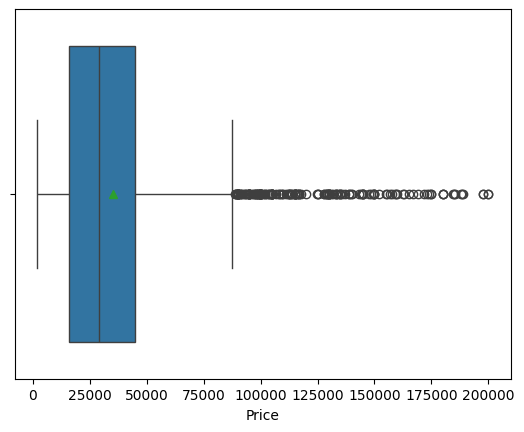

Mean: 35113.58227131124
25% Quantile 16000.0
75% Quantile 44998.5
Std: 27679.806746065507


In [11]:
# Your code here

plt.figure()
sns.boxplot(x='price', data=df, showmeans = True)
plt.xlabel('Price')
plt.show()

print("Mean:", np.mean(df['price']))
print("25% Quantile", df['price'].quantile(0.25))
print("75% Quantile", df['price'].quantile(0.75))
print("Std:", np.std(df['price']))

**Answer:** 

There are a lot of outliers on the higher end of prices. 25% of cars have prices below 16000 and 75% of the cars have prices below 45000. However prices range until about 200000, where there are less and less cars being that expensive. 

- Mean: 35113.58227131124
- 25% Quantile 16000.0
- 75% Quantile 44998.5
- Std: 27679.806746065507

We can see that the mean is higher than the median because the mean is effected by the higher outliers.

To get deeper insight into the price distribution, you decide to create a histogram. Choose an appropriate number of bins to get an informative plot. What do you observe? 

**[1 point]**

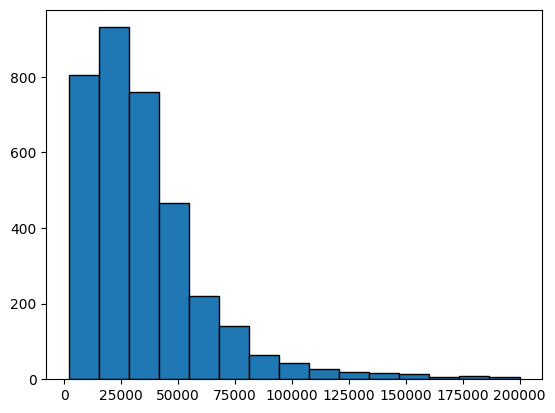

In [12]:
# Your code here
plt.figure()
plt.hist(df['price'], bins=15, edgecolor = 'k')
plt.show()

**Answer:** 

It seems like the number of cars is exponentially decreasing for higher prices, looking similar to a poisson distribution. Most cars seem to have a price around 25000.

## (b) Exploration of correlations **[10 points]**

Next, you want to investigate possible correlations of other variables with the target feature.

### (i) Correleation with numerical attributes

To do so, you create a correlation matrix of the numeric values of dataset. Intepret the correlation values you found between price and *model_year*, *milage*, *horsepower*, *litres*, and *cylinders*. 

**[3 points]**

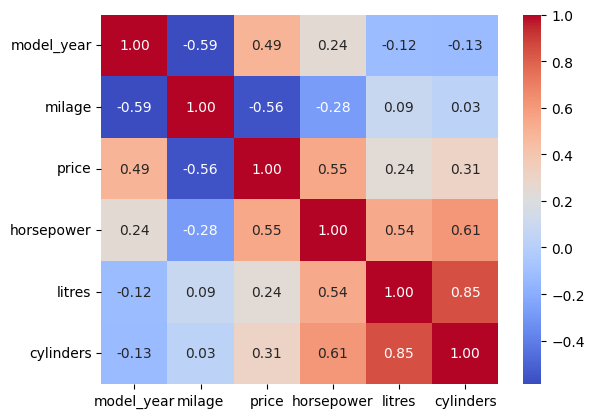

model_year    0.486867
milage       -0.558964
price         1.000000
horsepower    0.545003
litres        0.240132
cylinders     0.308251
Name: price, dtype: float64


In [13]:
# Your code here
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()
print(correlation_matrix['price'])

**Answer:**

Price has a positive correlation with all features except for milage where the correlation is negative.

- Positive corr: as one variable increases, the other variable also tends to increase
- Negative corr: as one variable increases, the other variable also tends to decrease

Price has the strongest correlation with milage and horsepower and the lowest with litres.


### (ii) Univariate correlations with categorical attributes

In the following, you consider the categorical attributes. You start with *brand*, *fuel_type*, *accident*, and *clean_title*. Create boxplots for these features to capture the relationship with *price*, also showing the mean. What do you observe? Are there feature values for which you can clearly identify a relationship to the price attribute? Also, comment on the outliers and potential distribution inside a value's prices. Be brief in your answers. 

**[2.5 points]**

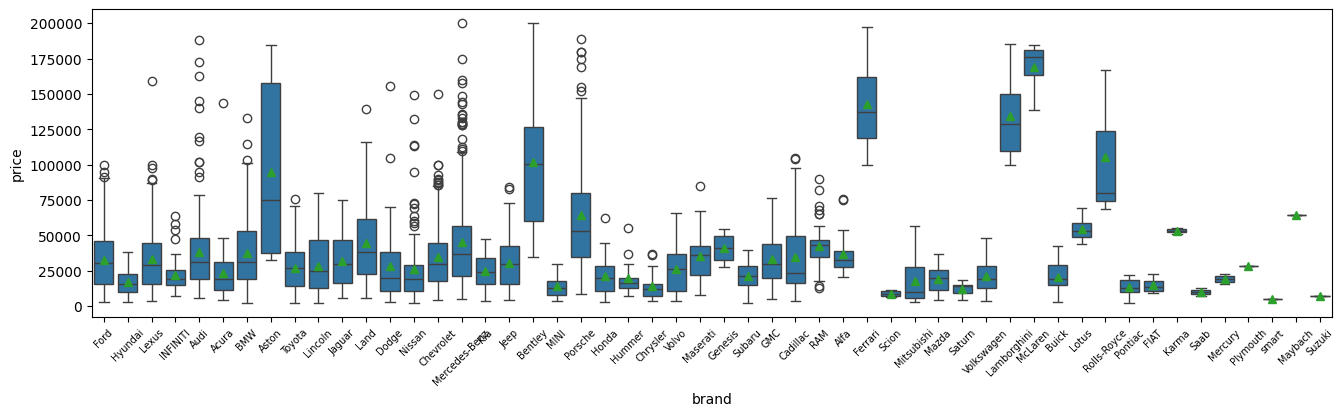

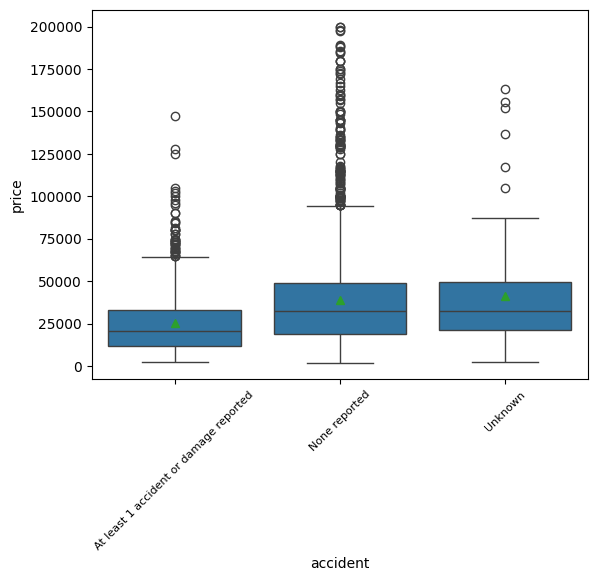

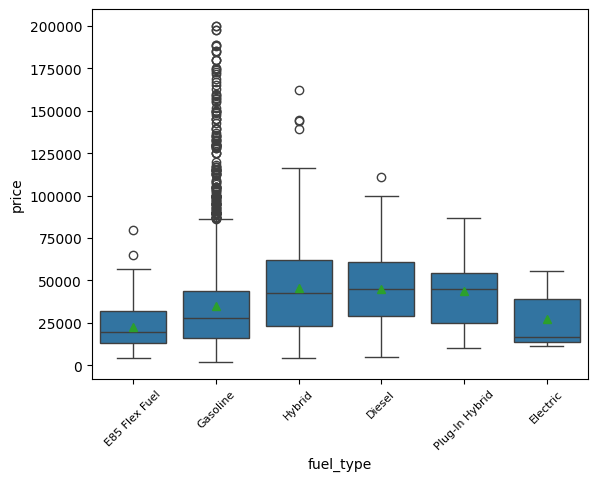

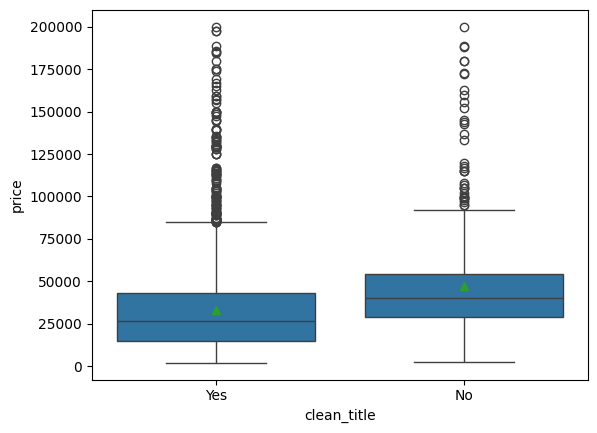

In [14]:
# Your code here
# Your code here
plt.figure(figsize=(16, 4))
ax = sns.boxplot(x='brand', y='price', data=df, showmeans=True)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=7)
plt.show()

ax = sns.boxplot(x='accident', y='price', data=df, showmeans=True)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
plt.show()

ax = sns.boxplot(x='fuel_type', y='price', data=df, showmeans=True)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
plt.show()

ax = sns.boxplot(x='clean_title', y='price', data=df, showmeans=True)
plt.show()

**Answer:**

*Brands:*
It is evident that luxury brands and sports cars such as Aston Martin, Bentley, Porsche, Ferrari, Lamborghini, McLaren, or Rolls-Royce are associated with higher prices. While Aston Martin, Porsche, and Bentley exhibit a wide spread of prices, Ferrari, Lamborghini, and McLaren cars consistently fall into the expensive range. Most other brands generally fall within the price range of 25,000 to 50,000, with some exceptional models being more expensive.

*Accident:*
As one would expect, cars without reported accidents tend to be more expensive than cars with reported accidents.

*Fuel Type:*
On average Hybrid, Plug-In Hybrid and Diesel cars tend to be the most expensive. However, the single most expensive cars use gasoline as Fuel as illustradet by the numerous higher outliers in the Gasoline boxplot.

*Clean Title:*
Cars that have the *No* value in the clean_title column appear to be slightly more expensive than cars that have a *Yes* value.

### (iii) Multivariate correlations with categorical attributes

As the current analysis provides limited insight, you want to include a multivariate view using boxplots that also show the mean. Again, you decide on *brand*, *fuel_type*, *accident*, and *clean_title* as features. You create a boxplot for each pair of features with *price* still being your target. Based on these, provide a **superficial** conclusion. Each of the following cells focuses on one feature in particular. 

*Hint*: You may want to use Seaborn's boxplot functionality while fixing the hue to each feature mentioned in the following cells (for inspiration, see, e.g., Seaborn's gallery: https://seaborn.pydata.org/examples/index.html)

**[2 points]**

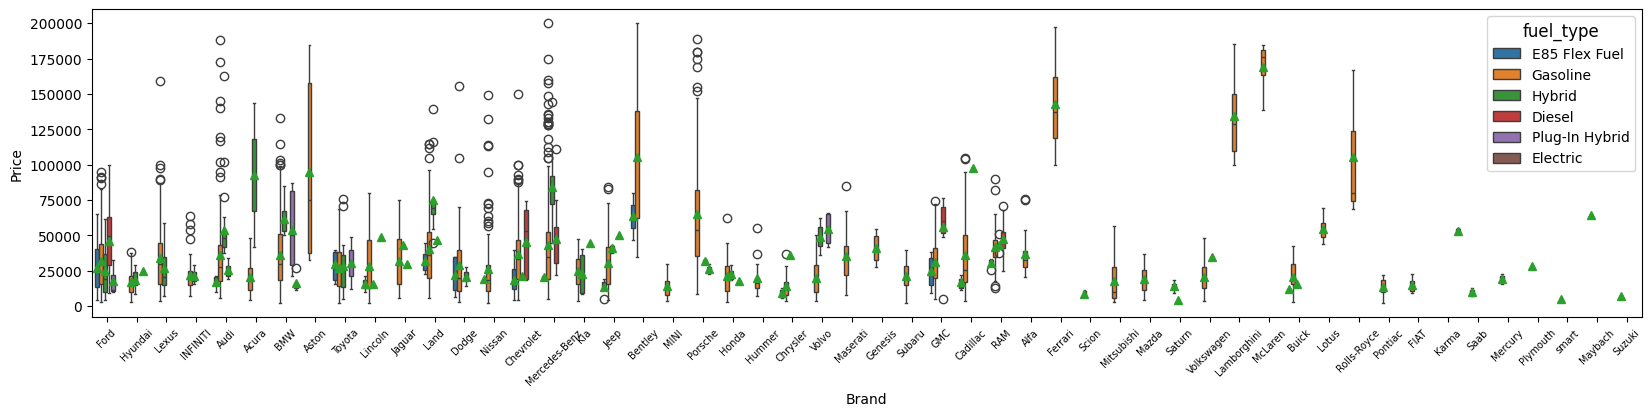

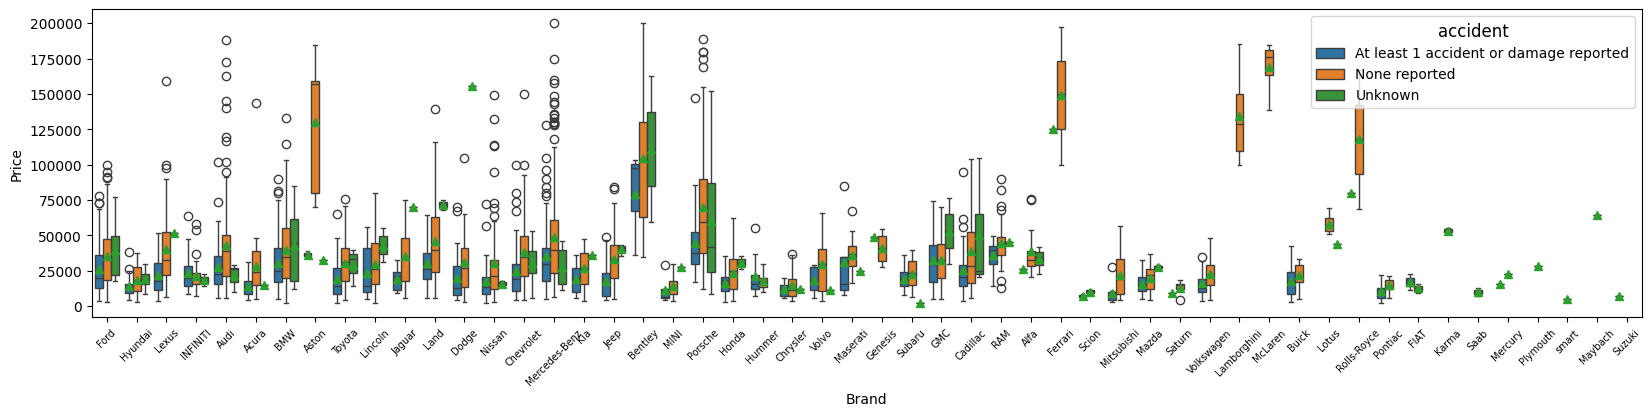

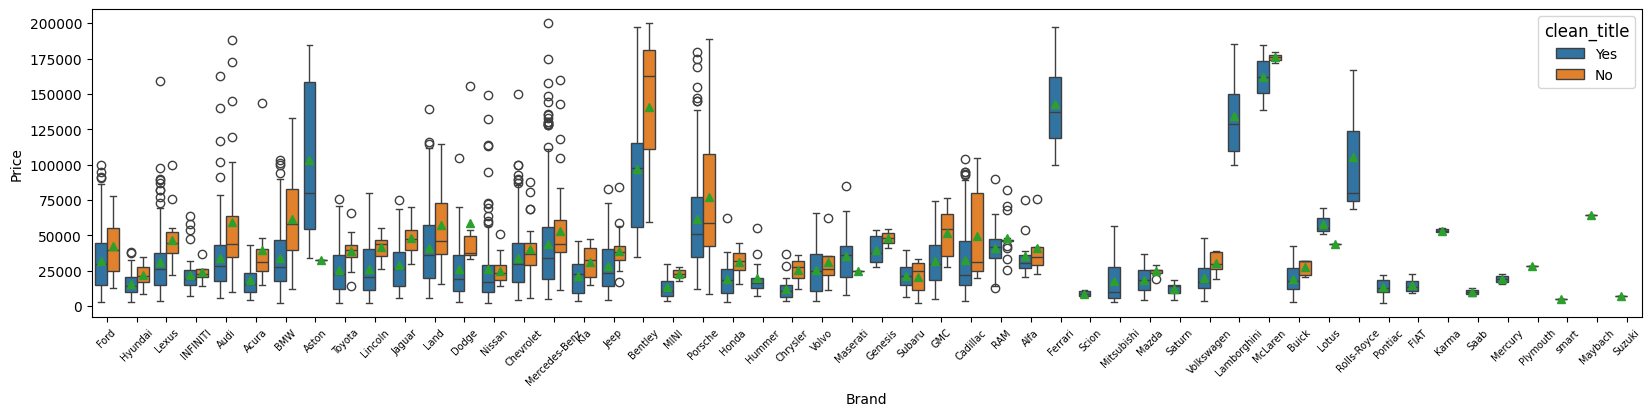

In [15]:
# Multivariate analysis for brand
# Your code goes here
attributes = ["fuel_type", "accident", "clean_title"]

for attribute in attributes:
    plt.figure(figsize=(20, 4))
    ax = sns.boxplot(x='brand', y='price', hue=attribute, data=df, showmeans=True, dodge=True)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=7)
    plt.xlabel('Brand')
    plt.ylabel('Price')
    plt.legend(title=attribute, title_fontsize='12', loc='upper right')
    plt.show()

**Answer: **[2 points]****

*Brand x Fuel Type:* We can see that the expensive brands almost exclusively use gasoline as fuel type which explains the correlation of the fuel type gasoline with high prices as seen above. As an additional result we obtain that the fuel types E85, Hybrid, Plug-In Hybrid and Electric are very rare among the brands.

*Brand x Accident:* For almost every brand the cars without a reported accident are more expensive than cars with reported accidents. Another observation is that expensive brands like Aston, Ferrari, Lamborghini and McLaren seem to have almost no reported accidents. These two facts lead to the result that cars without accident tend to be more expensive as stated above.

*Brand x Clean Title:* For almost all brands where we see both values (Yes and No) in the clean_title column it becomes evident that cars with no clean title tend to be more expensive.

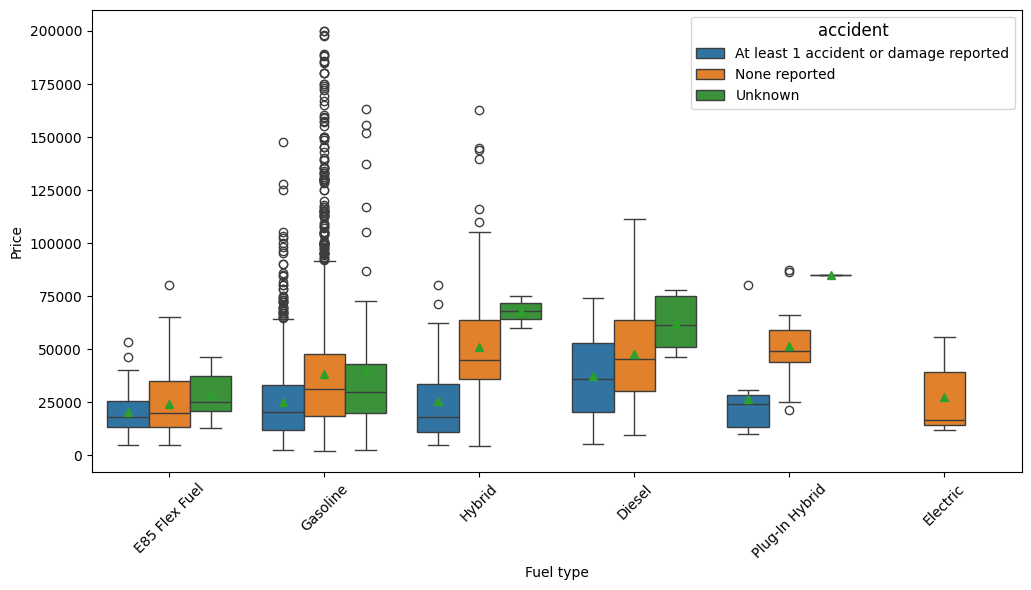

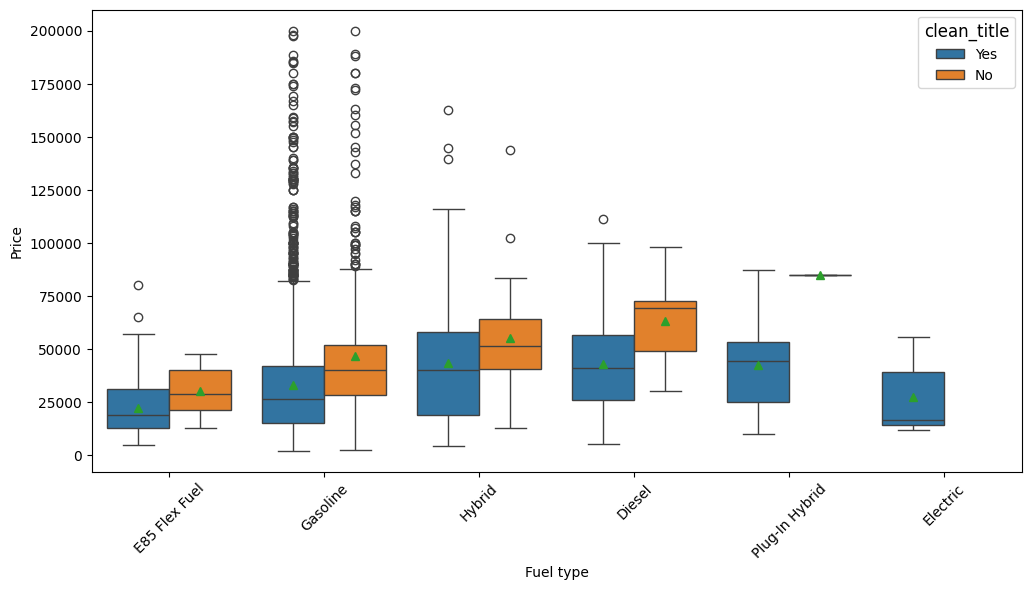

In [16]:
# Multivariate analysis for fuel_type
# Your code goes here
attributes = ["accident", "clean_title"]

for attribute in attributes:
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(x='fuel_type', y='price', hue=attribute, data=df, showmeans=True, dodge=True)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=10)
    plt.xlabel('Fuel type')
    plt.ylabel('Price')
    plt.legend(title=attribute, title_fontsize='12', loc='upper right')
    plt.show()

**Answer: **[1.5 points]****

*Fuel Type x Accident:*
As expected, cars with no reported accident are more expensive than cars with reported accidents, for every Fuel Type. However cars with the value unknown in the accident column are on average in many cases even more expensive. But there seem to be less cars having the value unknown than for the other two values, so this trend might not be that significant.

*Fuel Type x Clean Title:*
For every fuel type the same trend as above emerges with the No value corresponding to higher prices.

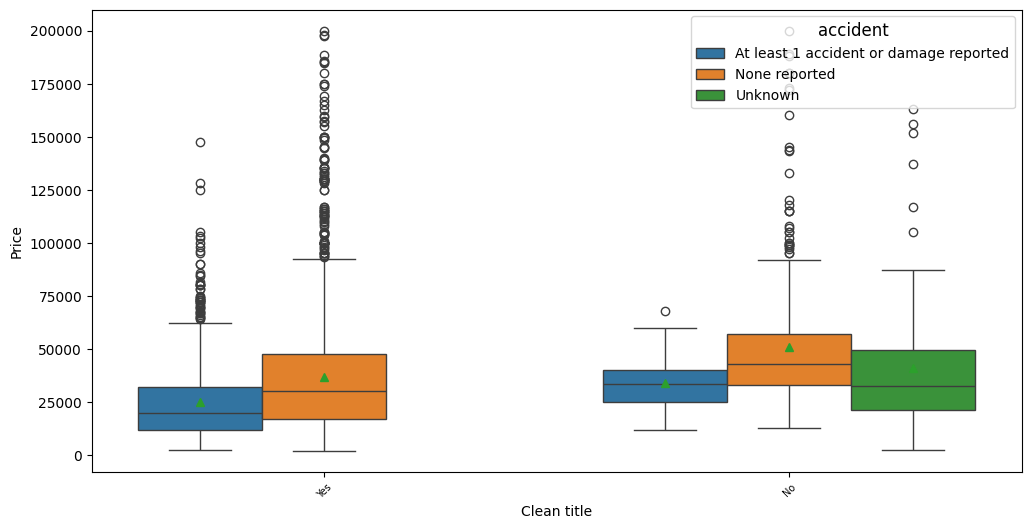

In [17]:
# Multivariate analysis for clean_title
# Your code goes here
attributes = ["accident"]

for attribute in attributes:
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(x='clean_title', y='price', hue=attribute, data=df, showmeans=True, dodge=True)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=7)
    plt.xlabel('Clean title')
    plt.ylabel('Price')
    plt.legend(title=attribute, title_fontsize='12', loc='upper right')
    plt.show()

**Answer: [1 point]**

*Clean Title x Accident:* For both values of clean_title cars with no reported accident are more expensive than cars with reported accidents. The most interesting observation from this plot might be that there are no cars with the Yes value in the clean_title column and the Unknown value in the accident column.

# Q3: Predicting prices **[62 points]**

After a long day at the office, you and N. go to a local bar to catch up with your old friend W. Over a round of cold drinks, you begin to share the great news about your booming business. Being an expert in data analytics himself, W. is also curious to hear your plans to apply your data science knowledge.

"I've been thinking about selling my old Porsche to make room for a new one," W. says to you. "I'm wondering what price to set for the old one. This is the perfect opportunity for you to try out your new predictive models, don't you think?"

You agree! W. writes down the properties of his Porsche (in the following, also referred to as *target car*) on a napkin. You tell W. that you will call him as soon as you can make a confident estimate for the price of his car. The next morning, you immediately start working on predictive models for car prices.
If not sated otherwise, you use the entire pre-processed dataset to create each of the models - load the dataset new at the beginning of every partial question a), b),...d) so you don't accidentally use data you have changed for a different kind of model. 


In [18]:
car = pd.DataFrame([{
      "brand": "Porsche",
      "model":  "911 Carrera S",
      "model_year": 2015,
      "milage": 84500.0,
      "fuel_type": "Gasoline",
      "engine": "400.0HP 3.8L Flat 6 Cylinder Engine Gasoline Fuel",
      "transmission": "7-Speed A/T",
      "ext_col": "Black",
      "int_col": "Black",
      "accident": "None reported",
      "clean_title": "Yes",
      "horsepower": 400.0,
      "litres": 3.8,
      "cylinders": 6.0
}])

## (a) Baseline **[2 points]**

First, you want to set a baseline to compare against. The baseline should always use the average price of all cars as a recommended price. Use the pre-processed dataset and the `train_test_split` from *sklearn* with arguments `random_state=3` and `test_size=0.05`. To stay consistent, the same split between training and test set should be used throughout the entire assignment.

What are the values of the mean absolute error and the root-mean-squared error? 

**[2 points]**

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
# Your code here

df = pd.read_csv("used_cars_preprocessed.csv")
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=3)

avg = y_train.mean()
baseline = np.full(len(y_test), avg)
mae = mean_absolute_error(y_test, baseline)
rme = mean_squared_error(y_test, baseline, squared=False)

print(f"Average price: {avg}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rme}")

Average price: 35025.14788312463
Mean Absolute Error: 20509.64840362633
Root Mean Squared Error: 30579.40498322031


## (b) Prediction by classification **[16 points]**

Next, you try to price your car according to similar cars using a decision tree.

### (i) Price binning

In the following, we want to know the price ranges for selling cars. To use decision trees, you need to discretize prices. We use the following price bins:
- [1,800, 10,000]
- (10,000, 20,000]
- (20,000, 30,000]
- (30,000, 40,000]
- (40,000, 50,000]
- (50,000, 60,000]
- (60,000, 80,000]
- (80,000, 100,000]
- (100,000, 120,000]
- (120,000, 140,000]
- (140,000, 160,000]
- (160,000, 180,000]
- (180,000, 220,000]

Add the attribute *Price_Bins* to the entire pre-processed data set using the discretization mentioned above for each car. For example, if a car costs 2500, it is put into the bin [1,800, 10,000]. 

**[1 point]**

In [20]:
# Your code here
price_bins = [1800, 10000, 20000, 30000, 40000, 50000, 60000, 80000, 100000, 120000, 140000, 160000, 180000, 220000]

# creating intervals with the pandas cut function
df['Price_Bins'] = pd.cut(df['price'], bins=price_bins, include_lowest=False, right=True)
print(df.head())

      brand                            model  model_year  milage  \
0      Ford  Utility Police Interceptor Base        2013   51000   
1   Hyundai                     Palisade SEL        2021   34742   
2     Lexus                    RX 350 RX 350        2022   22372   
3  INFINITI                 Q50 Hybrid Sport        2015   88900   
4      Audi        Q3 45 S line Premium Plus        2021    9835   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission ext_col int_col                                accident  \
0        6-Speed A/T   Black   Black  At least 1 accident or damage reported   
1  8

You predicted a price range for cars. However, since you cannot enter a price range for selling a car, you have to map each bin to a value. To do so, you use the mean of bins to predict the price. For example, the bin (10,000, 20,000] is mapped to 15,000. Create a dictionary you can use for this mapping. 

**[1 point]**

In [21]:
# Your code here
bins = df['Price_Bins'].unique()
bin_means = [(edge.left + edge.right)/2 for edge in bins]
bin_dict = dict(zip(bins, bin_means))
bin_dict

{Interval(10000, 20000, closed='right'): 15000.0,
 Interval(30000, 40000, closed='right'): 35000.0,
 Interval(50000, 60000, closed='right'): 55000.0,
 Interval(1800, 10000, closed='right'): 5900.0,
 Interval(40000, 50000, closed='right'): 45000.0,
 Interval(180000, 220000, closed='right'): 200000.0,
 Interval(60000, 80000, closed='right'): 70000.0,
 Interval(20000, 30000, closed='right'): 25000.0,
 Interval(140000, 160000, closed='right'): 150000.0,
 Interval(120000, 140000, closed='right'): 130000.0,
 Interval(80000, 100000, closed='right'): 90000.0,
 Interval(100000, 120000, closed='right'): 110000.0,
 Interval(160000, 180000, closed='right'): 170000.0}

### (ii) Data transformation for decision trees

You want to apply a decision tree to predict the price. You decide to use *brand*, *fuel_type*, *model_year*, *accident* and *clean_title* as descriptive features and *Price_Bins* as the target feature. 

You split the data into a train and test set. For the train-test split, use `train_test_split` from *sklearn* with arguments `random_state=3` and `test_size=0.05`

In order to apply the sklearn method for decision trees, you need to encode the categorical variables. For the encoding, use the `OneHotEncoder` from *sklearn* with `sparse_output=False`.
  
*Hint*: You later need the continous prices of your test set to compute errors, so better store them.

*Hint*: Applying `get_feature_names_out()` on your encoder provides you a list of columns after the transformation.

**[2 points]**

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
# Your code here
features = ['brand', 'fuel_type', 'accident', 'clean_title']
X = df[features]
y = df['Price_Bins']

encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X)
feature_names = encoder.get_feature_names_out(features)
df_transformed = pd.DataFrame(X_encoded, columns=feature_names)
df_transformed = pd.concat([df_transformed,df['model_year']], axis = 1)

X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(df_transformed, y, df['price'],
                                                                             test_size=0.05, random_state=3)
df_transformed.head()

,brand_Acura,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Buick,brand_Cadillac,brand_Chevrolet,brand_Chrysler,...,fuel_type_Electric,fuel_type_Gasoline,fuel_type_Hybrid,fuel_type_Plug-In Hybrid,accident_At least 1 accident or damage reported,accident_None reported,accident_Unknown,clean_title_No,clean_title_Yes,model_year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2013
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2021
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2022
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2015
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2021


### (iii) Model training

In the following, you want to use a good deicision tree for predicting prices. To do so,you want to test a set of different values, in particular, max depth of a tree. You test values in [1, 9] (in steps of size one).

You use the the algorithm from the *sklearn* library. You set as criterion "entropy", `min_samples_leaf=6`, and `random_state=42`.

Your goal is to minimize the mean absolute error. Create the prediction using the bins and only apply the dictionary mapping the bins to means to the predicted values before calculating the error. 

Create a summarizing plot, in which the x-axis represents the maximum tree depth, and the y-axis the mean absolute error as well as the root-mean-square error.

**[5 points]**

Condider your plot, which setting minimizes the mean absolute error and which minimizes the root-mean-square error? Which tree depth would you favorize and what are the error values? Round to the second decimal.  

**[2 point]**

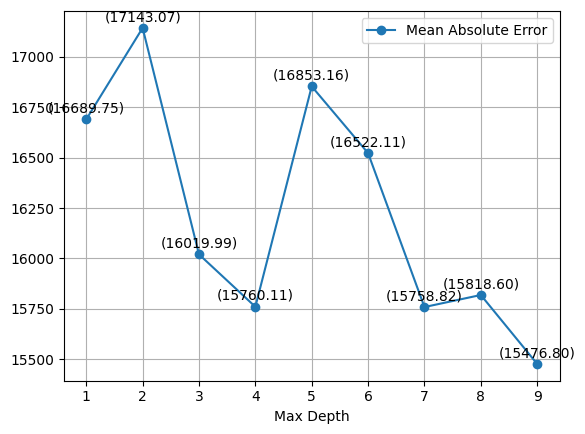

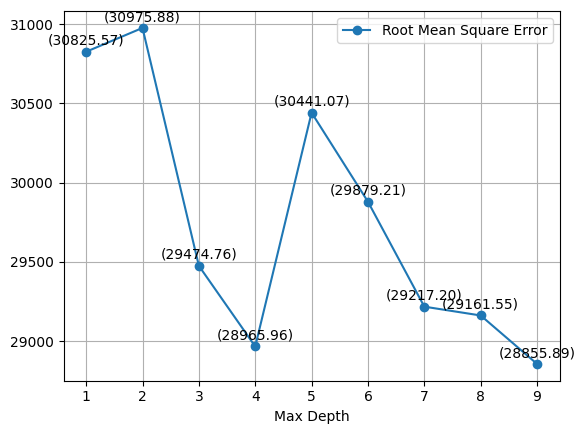

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn import tree
# Your code here

# Encoding the labels because I work with intervals and the decision tree can't handle that.
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

max_depth = np.arange(1, 10, 1)
mae_values = []
rme_values = []
models_dict = {}

# Iterate over max depth values
for m in max_depth:
    model = tree.DecisionTreeClassifier(
        criterion='entropy', min_samples_leaf=6, random_state=42, max_depth=m
    )
    model.fit(X_train, y_train_encoded)
    models_dict[m] = model
    y_pred_bins = model.predict(X_test)
    
    # I have to do inverse transformation to be able to map the bins to the mean
    y_pred = label_encoder.inverse_transform(y_pred_bins)
    y_pred = [bin_dict.get(y_pred[i]) for i in range(len(y_pred))]   
    
    # Calculate mean absolute error and root-mean-square error
    mae = mean_absolute_error(price_test, y_pred)
    rme = mean_squared_error(price_test, y_pred, squared=False)
    mae_values.append(mae)
    rme_values.append(rme)

plt.plot(max_depth, mae_values, label='Mean Absolute Error', marker='o')
for i, (xi, yi) in enumerate(zip(max_depth, mae_values)):
    plt.annotate(f'({yi:.2f})', (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')
plt.xlabel('Max Depth')
plt.grid(True)
plt.legend()
plt.show()

plt.plot(max_depth, rme_values, label='Root Mean Square Error', marker='o')
for i, (xi, yi) in enumerate(zip(max_depth, rme_values)):
    plt.annotate(f'({yi:.2f})', (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')
plt.xlabel('Max Depth')
plt.legend()
plt.grid(True)
plt.show()

**Answer:**

The lowest MAE with 15476.80 and RMSE with 28855.89 corresponds to the depth 9. However I would choose depth 4 with MAE=15760.11 and RMSE=28965.96 because it is the third/second best tree only slightly worse than depth 9. The great advantage is that a smaller tree is easily interpretable and understandable.

Create and plot the tree. What is the first attribute to split on? 

**[2 points]**


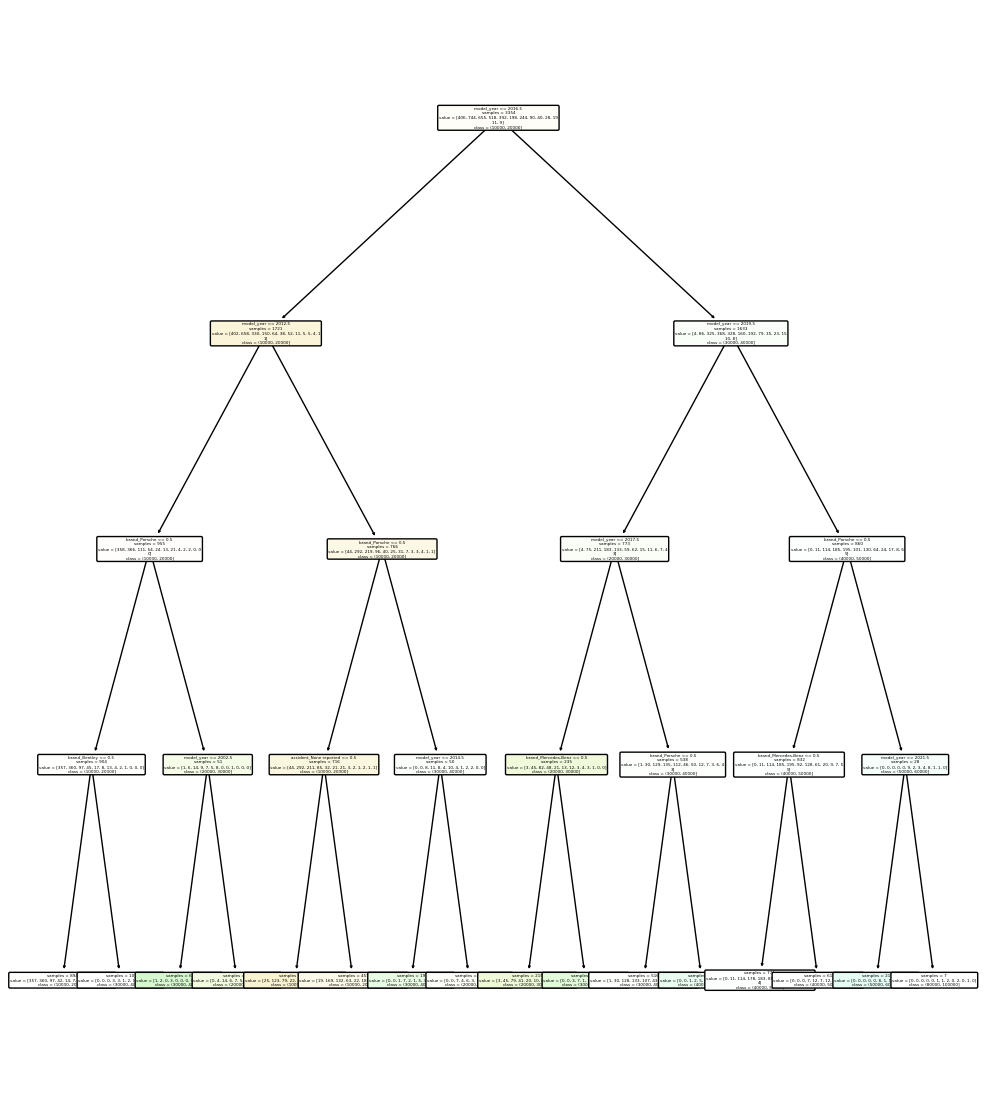

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Your code here

plt.figure(figsize=(12, 14))
plot_tree(models_dict.get(4), filled=True, feature_names=X_train.columns,
          class_names=label_encoder.classes_.astype(str), rounded=True,
          impurity=False, fontsize=3)
#Saving the plot with high resolution
plt.savefig('tree.png', dpi=300) 
plt.show()

**Answer:** 

Model_year is the first attribute to split on. To be precise the first decision is Model year <= 2016.5.

What price range does your tree suggest for the following cars:

- Porsche, 2004, Gasoline, none accident, and clean title
- Mercedes-Benz, 2017, Hybrid, unknown accident, and clean title

**[2 points]**

In [25]:
input_cars = pd.DataFrame([
    {"brand": "Porsche", "model_year": 2004, "fuel_type": "Gasoline", "accident": "None reported", "clean_title": "Yes"},
    {"brand": "Mercedes-Benz", "model_year": 2017, "fuel_type": "Hybrid", "accident": "Unknown", "clean_title": "Yes"}
])

input_cars_encoded = encoder.transform(input_cars[['brand', 'fuel_type', 'accident', 'clean_title']])
feature_names = encoder.get_feature_names_out(features)
input_cars_transformed = pd.DataFrame(input_cars_encoded, columns=feature_names)
input_cars_transformed = pd.concat([input_cars_transformed,input_cars['model_year']], axis = 1)

y_pred_bins = models_dict.get(4).predict(input_cars_transformed)
label_encoder.inverse_transform(y_pred_bins)

array([Interval(20000, 30000, closed='right'),
       Interval(30000, 40000, closed='right')], dtype=object)

**Answer**:


    Porsche, 2004, Gasoline, none accident, and clean title: 20000-30000
    Mercedes-Benz, 2017, Hybrid, unknown accident, and clean title: 30000-40000


### (iv) Price prediction

Finally, use the decision tree to predict the price of W.'s car. What is the predicted price? Derive the value from the visualized tree manually (do not use the model's `predict` method). Provide the mean, not the bin.

**[1 point]**

**Answer**: 

25000

1. Model Year <= 2016.5
2. Model Year > 2012.5
3. Brand Porsche > 0.5
4. Model Year > 2014.5

## (c) Prediction by clustering **[21 points]**

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import DistanceMetric
from sklearn.cluster import DBSCAN
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statistics

In [27]:
# Import dataset
df = pd.read_csv("used_cars_preprocessed.csv")

You come up with another idea to give W. an estimate on his car price. You want to use clustering to find similar cars and use their average price as an estimate.

In this task you use DBSCAN to determine clusters of similar cars. For each cluster, you calculate the mean price as a representative. To predict the price for new cars, you assign it to an existing cluster and give the mean price as prediction.

### (i) Data transformation for clustering 

Use *brand*, *milage*, *fuel_type*, *accident*, *clean_title* and *horse_power* as descriptive features and *price* as the target feature. Create a test and training set like before. For the train-test split, use again `train_test_split` from *sklearn* with arguments `random_state=3` and `test_size=0.05`. 

**[1 point]**

In [28]:
# Your code here
X_DBSC = df[['brand', 'milage', 'fuel_type', 'accident', 'clean_title', 'horsepower']]
y_DBSC = df['price']
X_train_DBSC, X_test_DBSC, y_train_DBSC, y_test_DBSC = train_test_split(
    X_DBSC, y_DBSC, test_size=0.05, random_state=3
)
y_train_DBSC = y_train_DBSC.reset_index(drop=True)
X_train_DBSC = X_train_DBSC.reset_index(drop=True)

### (ii) Computing the distance matrix

DBSCAN determines clusters based on the distance between different data points. Since some of the features you want to use are not numeric, you have to apply some encoding first to be able to use distance measures. 

For categorical variables, apply ordinal encoding and compute the Hamming distance; for numerical variables, apply standard scaling and compute the Euclidean distance.

For the total distance, first, weight the distance of categorical features by the fraction of categorical variables among the complete feature set. Then, add the distance of numerical features weighted by 1 over the total number of features used.

In other words: Let $x=(x_{cat},x_{num})^T$ and $y=(y_{cat},y_{num})^T$ be two samples where $x_{cat}$ and $y_{cat}$ represent their categorical features, and $x_{num}$ and $y_{num}$ represent their numerical features. Let $n_{cat}$ be the number of categorical features and $n_{num}$ be the number of numerical features. Then, the total distance $d_{tot}(x,y)$ between $x$ and $y$ is given by

$d_{tot}(x,y)=\dfrac{n_{cat}\cdot\Delta(x_{cat},y_{cat})+d(x_{num},y_{num})}{n_{cat}+n_{num}}$

where $\Delta$ is the Hamming distance and $d$ is the Euclidean distance.

Provide a matrix of the computed pairwise total distance between all cars in the training set. Keep the same indexing as in the training set.

**[4 points]**

*Hint*: Use the preprocessing module of sklearn to prepare your dataset for clustering.

*Background*: The Hamming distance is already normed on the number of features used and therefore returns a value between 0 and 1 independent from the number of variables.

In [29]:
# Your code here
from sklearn.pipeline import Pipeline

categorical_selector = make_column_selector(dtype_include='object')
numerical_selector = make_column_selector(dtype_include=np.number)
preprocessor_cluster = make_column_transformer(
    (OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan), categorical_selector),
    (StandardScaler(), numerical_selector)
)
X_train_transformed = preprocessor_cluster.fit_transform(X_train_DBSC)

hamming_metric = DistanceMetric.get_metric('hamming')
euclidean_metric = DistanceMetric.get_metric('euclidean')

# We have 4 categorical and 2 numerical features. I use these numbers in the calculations
pairwise_distance_matrix = hamming_metric.pairwise(X_train_transformed[:, :4]) * 4
pairwise_distance_matrix += euclidean_metric.pairwise(X_train_transformed[:, 4:])
pairwise_distance_matrix /= 2 + 4

# Display the matrix
print(pairwise_distance_matrix)

[[0.         0.66176054 0.6191782  ... 0.55709901 0.61484066 0.2560623 ]
 [0.66176054 0.         0.49621385 ... 0.39089873 0.21483893 0.59175826]
 [0.6191782  0.49621385 0.         ... 0.27976761 0.46058016 0.54771068]
 ...
 [0.55709901 0.39089873 0.27976761 ... 0.         0.35112094 0.46977129]
 [0.61484066 0.21483893 0.46058016 ... 0.35112094 0.         0.54359799]
 [0.2560623  0.59175826 0.54771068 ... 0.46977129 0.54359799 0.        ]]


**Note**: From here on, instead of the distance matrix computed before, use the one provided in `distance.txt`.

In [30]:
# load the new distance matrix
dist = np.genfromtxt("distance.txt", delimiter=",")

### (iii) Applying DBSCAN

According to a common heuristic, set the minPts parameter of DBSCAN to twice the number of features. Show the according k-distance plot (where *k = minPts - 1*).

**[1 point]**

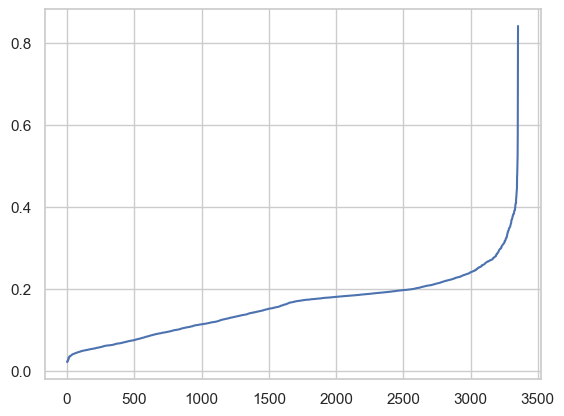

In [31]:
# Your code here

# We have 6 features, therefore min_pts = 2*6 = 12
min_pts = 12

# similar to the exercise about dbscan
from sklearn.metrics.pairwise import euclidean_distances
dist.sort(axis=0)
dist.sort()

sns.set_theme(style="whitegrid")
sns.lineplot(dist[min_pts-1])
plt.show()

Now you have to determine values for the *epsilon* parameter. Based on the previous plot, perform DBSCAN where you vary *epsilon* in the interval (0.0, 0.3] by steps of 0.01.

Draw a diagram with the parameter *epsilon* (between 0.01 and 0.3) on the x-axis and the percentage of 
- clustered samples,
- samples in the largest component,
- and noise

on the y-axis.

In a second diagram, plot the number of clusters over *epsilon*.

Based on these diagrams, which value for *epsilon* seems to be most suitable? Explain your answer. 

**[4 points]**

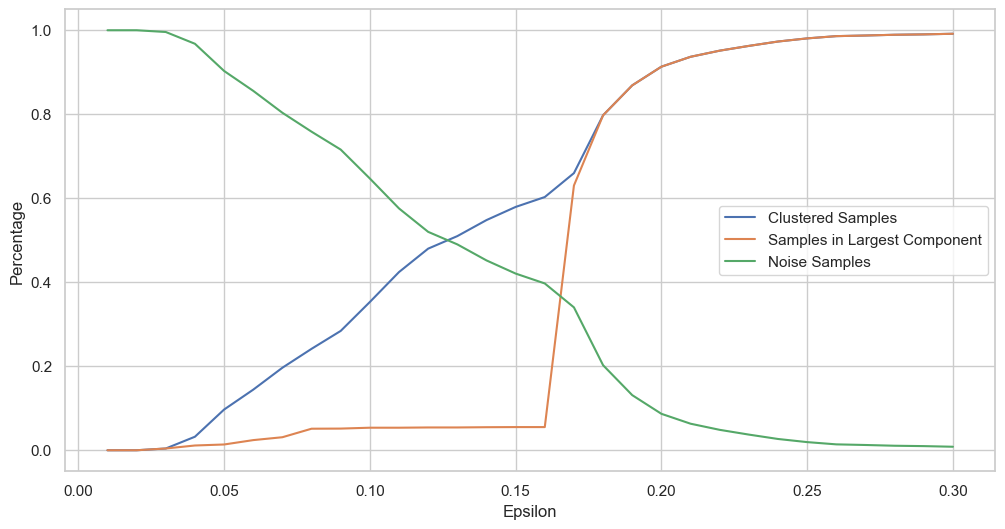

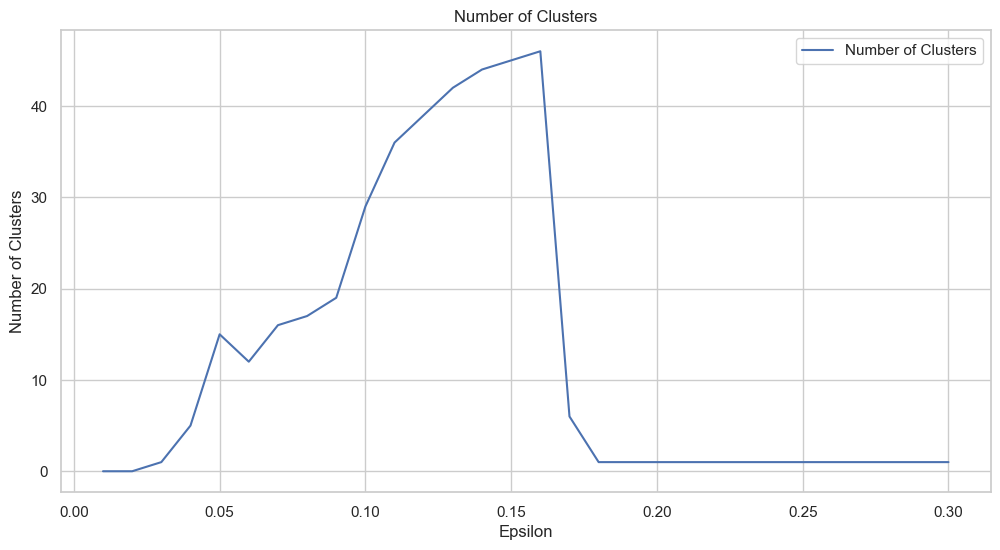

In [32]:
# Your code here
dist = np.genfromtxt("distance.txt", delimiter=",")
epsilons = np.arange(0.01, 0.31, 0.01)

percentage_clustered = []
percentage_largest_component = []
percentage_noise = []
num_clusters = []

for epsilon in epsilons:
    dbscan = DBSCAN(eps=epsilon, min_samples=12, metric='precomputed')
    labels = dbscan.fit_predict(dist)
    
    total_samples = len(labels)
    clustered_samples = np.sum(labels != -1)
    noise_samples = np.sum(labels == -1)
    largest_component = np.max(np.bincount(labels[labels != -1])) if len(labels[labels != -1]) > 0 else 0
    
    percentage_clustered.append(clustered_samples / total_samples)
    percentage_largest_component.append(largest_component / total_samples)
    percentage_noise.append(noise_samples / total_samples)
    num_clusters.append(len(set(labels)) - (1 if -1 in labels else 0))

# Plot percentages
plt.figure(figsize=(12, 6))
plt.plot(epsilons, percentage_clustered, label='Clustered Samples')
plt.plot(epsilons, percentage_largest_component, label='Samples in Largest Component')
plt.plot(epsilons, percentage_noise, label='Noise Samples')
plt.xlabel('Epsilon')
plt.ylabel('Percentage')
plt.legend()
plt.show()

# Plot number of clusters
plt.figure(figsize=(12, 6))
plt.plot(epsilons, num_clusters, label='Number of Clusters')
plt.xlabel('Epsilon')
plt.ylabel('Number of Clusters')
plt.title('Number of Clusters')
plt.legend()
plt.show()

**Answer**: 

There seems to be a big jump from epsilon=0.16 to epsilon=0.17. So there are a lot of clusters being mere later ged at this point. I would choose epsilon=0.16 since we have more clustered points than noice while still having a lot of clusters. For this application having a lot of clusters might be an advantage because there is a wide range of values in our target feature and we want to do prediction later on.

**Note**: No matter the conclusion made in the previous task, from now on, use the clustering model with *epsilon = 1/6* for predicting the price of W.'s car and evaluating the clustering technique.

Apply DBSCAN clustering to your training set based on the provided distance matrix. Answer the following questions:
- How many clusters are identified?
- What is their average size?
- What is the size of the largest cluster (absolute and relative)?
- How large is the percentage of unclustered samples (noise)?

**[4 points]**

In [33]:
# Your code here
dbscan = DBSCAN(eps=1/6, min_samples=2 * 6, metric='precomputed')
labels = dbscan.fit_predict(dist)

# Calculate cluster statistics
unique_labels, cluster_sizes = np.unique(labels, return_counts=True)
num_clusters = len(unique_labels) - 1  # Exclude noise label (-1)
average_cluster_size = np.mean(cluster_sizes[1:]) 
largest_cluster_size = np.max(cluster_sizes[1:]) if num_clusters > 0 else 0
relative_largest_cluster_size = largest_cluster_size / len(labels)
percentage_unclustered = np.sum(labels == -1) / len(labels)

print(f"Clusters identified: {num_clusters}")
print(f"Average size: {average_cluster_size:.2f}")
print(f"Largest cluster (absolute): {largest_cluster_size}")
print(f"Largest cluster (relative): {relative_largest_cluster_size:.2%}")
print(f"Unclustered samples (noise): {percentage_unclustered:.2%}")

Clusters identified: 40
Average size: 51.75
Largest cluster (absolute): 321
Largest cluster (relative): 9.57%
Unclustered samples (noise): 38.28%


### (iv) Price prediction

Create a dataframe based on the training set where you assign each to each car the label of its corresponding cluster. Then, for each of the obtained clusters, compute their average price as an estimate. 

**[2 point]**

In [34]:
# Your code here

X_train_DBSC['cluster_label'] = labels
cluster_avg_prices = pd.concat([X_train_DBSC,y_train_DBSC],axis=1).groupby('cluster_label')['price'].mean()

cluster_price_estimates = pd.DataFrame({
    'cluster_label': cluster_avg_prices.index,
    'average_price_estimate': cluster_avg_prices.values
})

print(cluster_price_estimates)

    cluster_label  average_price_estimate
0              -1            33746.545950
1               0            37169.400826
2               1            34767.532143
3               2            43623.623053
4               3            30018.549296
5               4            45580.918239
6               5            34591.468085
7               6            30460.666667
8               7            27376.761905
9               8            63145.000000
10              9            25938.207547
11             10            42265.266667
12             11            66614.548387
13             12            93120.142857
14             13            35596.833333
15             14            17606.600000
16             15            28790.968750
17             16            23895.806452
18             17            20857.904762
19             18            59543.375000
20             19            44504.517241
21             20            15019.923077
22             21            24500

Use your test set to evaluate your prediction. Therefore, estimate the price of each car in the test set based on an appropriate corresponding cluster. 

*Hint*: To do that, determine the labels of neighboring cars and assign a label to  each car of the test set as if it were a point still to cluster by DBSCAN. 

Based on the previously computed average price of each cluster and your function, give a price estimate for each car in the test set.

Compare your estimates with the true prices. What are the values of the mean absolute error and the root-mean-square error? 

**[4 points]**

*Note*: The distance matrix between test and training set is provided in `distance_test_to_train.txt`.

In [35]:
test_dist = np.genfromtxt("distance_test_to_train.txt", delimiter=",")

In [36]:
# Your code here
n,m = np.shape(test_dist)
from sklearn.metrics import mean_absolute_error, mean_squared_error

# When predicting with dbscan there is no well defined way to do so.
# For me the most sensible is to use the most common cluster amongst the neighboring core points
from collections import Counter
def most_common_integer(lst):
    if not lst:
        return -1
    most_common, most_common_count = Counter(lst).most_common(1)[0]
    return most_common

DBSCAN_predict = []

for i in range(n):
    neighbor_indices = []
    for j in range(m):
        if test_dist[i,j]<=1/6:
            # check if point is core point
            if j in dbscan.core_sample_indices_:
                neighbor_indices.append(labels[j]) 
    label = most_common_integer(neighbor_indices)
    DBSCAN_predict.append(cluster_price_estimates['average_price_estimate'][label+1])

mae = mean_absolute_error(y_test_DBSC, DBSCAN_predict)
rme = np.sqrt(mean_squared_error(y_test_DBSC, DBSCAN_predict))
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rme)

Mean Absolute Error: 20141.90955738165
Root Mean Squared Error: 30149.768713658978


**Answer**:

1. MAE = 20141.91
2. RMSE: 30149.77

Finally, to predict the price for the target car, find a cluster that contains cars with similar features. 

**Note**: The distance matrix between the target car and the training set is provided in `distance_car_to_train.txt`.

Show the cars within a distance of *epsilon* to W's car including all used features, their price and the label of their cluster.

Which cluster would you assign the target car to and what is the estimated price? Round to the second decimal. 

**[1 point]**

In [37]:
car_dist = np.genfromtxt("distance_car_to_train.txt", delimiter=",")

In [38]:
# Your code here
neighbor_indices = []
for j in range(m):
    if car_dist[j]<=1/6:
        row_to_print = X_train_DBSC.iloc[j]
        print(f"All features of car {j}:\n{row_to_print}")
        print(f"Price: {y_train_DBSC[j]}\n")
        neighbor_indices.append(labels[j])
label = most_common_integer(neighbor_indices)
print(f"Label: {label}")
print(f"Estimated price: {cluster_price_estimates['average_price_estimate'][label+1]}")

All features of car 32:
brand                  Porsche
milage                   42635
fuel_type             Gasoline
accident         None reported
clean_title                Yes
horsepower               355.0
cluster_label                2
Name: 32, dtype: object
Price: 72995

All features of car 87:
brand                  Porsche
milage                   48900
fuel_type             Gasoline
accident         None reported
clean_title                Yes
horsepower               350.0
cluster_label                2
Name: 87, dtype: object
Price: 62500

All features of car 160:
brand                  Porsche
milage                  126000
fuel_type             Gasoline
accident         None reported
clean_title                Yes
horsepower               400.0
cluster_label                2
Name: 160, dtype: object
Price: 17999

All features of car 245:
brand                  Porsche
milage                   60000
fuel_type             Gasoline
accident         None reported
clean_title 

**Answer**: 

All close data points are from cluster 2, therefore we assign the car to cluster 2. The estimated price is 43623.62.

## (d) Prediction by regression and with neural networks **[17 points]**

In this task, we build regression models and neural networks to predict the car prices.

Use the dataset *used_cars_preprocessed.csv* for this subtask as well as the next.

In [39]:
import pandas as pd
df = pd.read_csv("used_cars_preprocessed.csv")

### (i) Feature engineering

Run the code below that derives a feature *average_model_price* and adds it to the entries in the dataset and to the target car.

Do you expect that using this feature as a descriptive feature will be beneficial for the quality of price prediction models? Discuss possible advantages and disadvantages. 

**[2 points]**

*Hint:* You can also first play around with different feature selections in the model training tasks below below to get a feeling for the usefulness of features.

In [40]:
average_model_prices = {
    model: df[df["model"] == model]["price"].mean()
    for model in set(df["model"].values)
}

df["average_model_price"] = df.apply(lambda row: average_model_prices[row["model"]], axis = 1)
car["average_model_price"] = car.apply(lambda row: average_model_prices[row["model"]], axis = 1)

# choosing suitable features to calculate the correlation
df_encoded = pd.get_dummies(df, columns=['fuel_type', 'accident', 'clean_title'])
correlation_matrix = df_encoded.corr(numeric_only = True)
correlation_with_target = correlation_matrix['price'].sort_values(ascending=False)
print(correlation_with_target)

price                                              1.000000
average_model_price                                0.942323
horsepower                                         0.545003
model_year                                         0.486867
cylinders                                          0.308251
litres                                             0.240132
accident_None reported                             0.196618
clean_title_No                                     0.177751
fuel_type_Hybrid                                   0.083568
fuel_type_Diesel                                   0.064116
accident_Unknown                                   0.036206
fuel_type_Plug-In Hybrid                           0.028566
fuel_type_Electric                                -0.012998
fuel_type_Gasoline                                -0.038486
fuel_type_E85 Flex Fuel                           -0.090462
clean_title_Yes                                   -0.177751
accident_At least 1 accident or damage r

**Answer:**

Of course the average model price is a very good feature to predict the price. Obviously it captures a lot of information about the price and cars with the same model might have similar prices. This feature has by far the highest correlation with price, but we are making two strategical mistakes: 
1. We use the target feature price to create a feature for our prediction task. We will have a problem if we want to use this prediction model on unseen cars where the price is not known. Since in this case we have a hard time figuring out the average model price. Especially if the model is one that is not included in our dataset yet. 
2. It gets even worse because we are using data from our entire data set (including the test set) to create this feature therefore our model might perform better in testing than on unseen data. The test data needs to be unseen otherwise the testing is useless.

The feature itself also has some disadvantages:
1. If there is a wide range of prices for a specific model, using the average might not accurately represent the diversity of prices within that model.
2. If certain models have outliers the average might be influenced by these outliers and may not reflect the majority of prices.

Conclusion: Including this feature will get us good results in training and testing but we are making a horrible mistake because the model can not generalize on unseen data and is therefore completely useless! (This would be different if we had an average model price from the producers of the model but we can NEVER use the target feature!!)

### (ii) Feature selection

As descriptive features for the models trained in the following, use as categorical feature *accident* and as numerical features *model_year* and *milage*. Depending on your answer for task (i), make a choice whether to include or not to include *average_model_price*.

Beside these features, choose one of the three numerical features *horsepower*, *cylinders* and *litres* as another descriptive feature. Motivate your choice with the help of appropriate visualization techniques. 

**[1 point]**

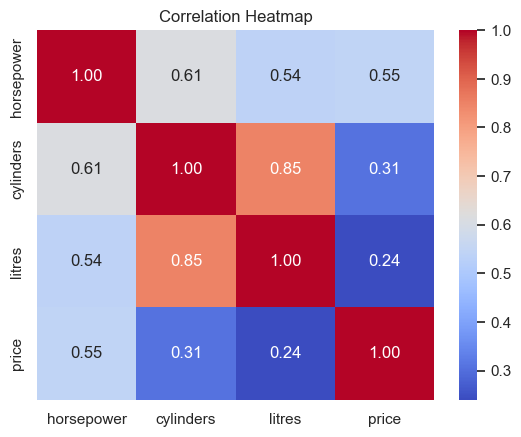

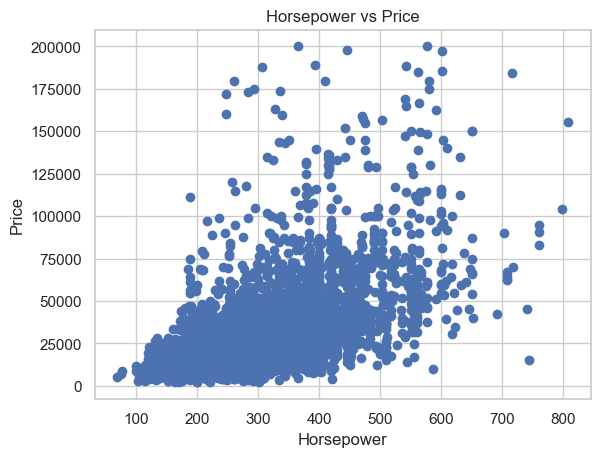

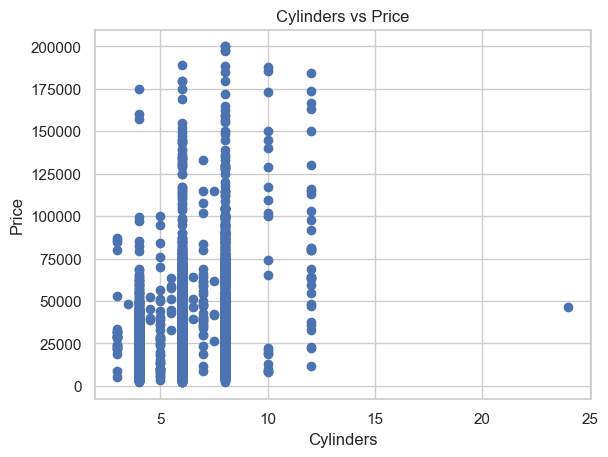

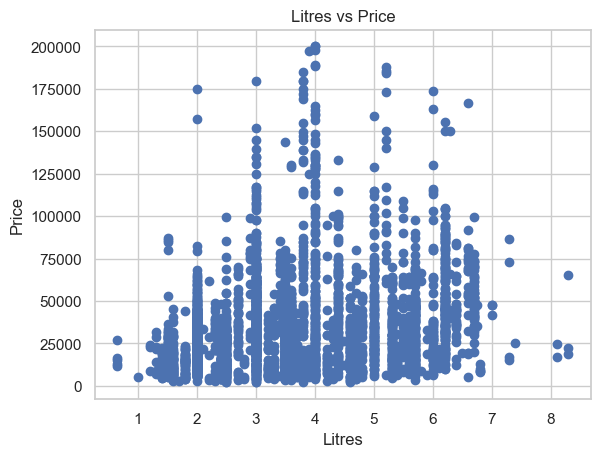

In [41]:
# Your code here
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = ['horsepower', 'cylinders', 'litres', 'price']
selected_df = df[selected_features]

# Correlation matrix
correlation_matrix = selected_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Scatter plots
plt.scatter(df['horsepower'], df['price'])
plt.title('Horsepower vs Price')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.show()

plt.scatter(df['cylinders'], df['price'])
plt.title('Cylinders vs Price')
plt.xlabel('Cylinders')
plt.ylabel('Price')
plt.show()

plt.scatter(df['litres'], df['price'])
plt.title('Litres vs Price')
plt.xlabel('Litres')
plt.ylabel('Price')
plt.show()

**Answer**

Based on the first task I am NOT including average model price. Instead I choose horsepower since it is the feature which has the highest correlation with price. And it is the only feature where you can actually see the correlation in the scatterplot. Additionally horsepower has a high correlation to litres and cylinders so it captures a lot of the information within those features.

### (iii) Data transformation for regression and neural networks

Use *accident*, *model_year* and *milage* as well as your selection from the previous task as descriptive features and *price* as the target feature. Create a test and training set like before, encoding the categorical feature. For the train-test split, use again `train_test_split` from *sklearn* with arguments `random_state=3` and `test_size=0.05`. 

Normalize the training and test sets as well as the target car. Use the `StandardScaler` from *sklearn* for normalization.

*Hint:* Append the target car to the dataset during the encoding procedure.

**[2 points]**


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X_reg = df[['accident', 'model_year', 'milage', 'horsepower']]
y_reg = df['price']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.05, random_state=3)
y_train_reg = y_train_reg.reset_index(drop=True)
y_test_reg = y_test_reg.reset_index(drop=True)
X_train_reg = X_train_reg.reset_index(drop=True)
X_test_reg = X_test_reg.reset_index(drop=True)

# Append the target car to the test data
X_test_reg = pd.concat([X_test_reg, car])

numerical_features = ['model_year', 'milage', 'horsepower']
categorical_features = ['accident']
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])
preprocessor_reg.fit(X_train_reg)

# Transform the training and test data
X_train_transformed = preprocessor_reg.transform(X_train_reg)
X_test_transformed = preprocessor_reg.transform(X_test_reg)

columns = numerical_features + list(preprocessor_reg.named_transformers_['cat'].get_feature_names_out(categorical_features))
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=columns)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=columns)
target_car = X_test_transformed_df.iloc[-1].to_frame().T
X_test_transformed_df = X_test_transformed_df.drop(X_test_transformed_df.index[-1])

X_train_transformed_df

,model_year,milage,horsepower,accident_At least 1 accident or damage reported,accident_None reported,accident_Unknown
0,0.873444,-0.851360,-0.533315,1.0,0.0,0.0
1,0.177221,0.065164,1.211135,0.0,1.0,0.0
2,0.003166,0.862479,-0.598268,0.0,1.0,0.0
3,0.873444,-1.025797,0.348189,1.0,0.0,0.0
4,0.351277,0.026270,0.654395,1.0,0.0,0.0
...,...,...,...,...,...,...
3349,1.221556,-1.112568,-0.097203,0.0,1.0,0.0
3350,0.873444,-0.634918,-0.310619,0.0,1.0,0.0
3351,0.177221,0.415205,-0.087924,0.0,1.0,0.0
3352,-0.867113,-0.012623,0.932765,0.0,1.0,0.0


In the following, we will train and evaluate various models for price prediction using the *sklearn* library. To leverage the shared interface for models in the sklearn library, it is convenient to create a function for the model training and evaluation.

### (iv) Model training function

Implement the body of the function *model_training* below. The function should adhere to the following specification:

#### Input:
- **model**: A model (e.g., Linear Regression or Neural Network) of the sklearn library.
- **x_training_data**: The descriptive data to train the model.
- **y_training_data**: The corresponding values of target feature of the training data.
- **x_test_data**: The descriptive data to test the model.
- **y_test_data**: The corresponding values of target feature of the test data.
- **grid_params**: Model parameters for a grid search.

#### Output:
- **grid**: An object of the class sklearn.model_selection.GridSearchCV that was fitted against the training data. The training should follow a 5-fold cross-validation.
- **mean_abs_err**: The mean absolute error of the trained model on the passed test data.
- **rms_err**: The root-mean-square error of the trained model on the passed test data.
- **best_params**: The optimal parameter configuration, i.e., the parameters of the best scoring model that was selected by the grid search.

**[2 points]**

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

def model_training(model, x_training_data, y_training_data, x_test_data, y_test_data, grid_params):
    grid = None
    best_params = None
    mean_abs_err = None
    # # # # # # # # # #
    # Your code here  #
    # # # # # # # # # #
    grid = GridSearchCV(model, grid_params, cv=5, verbose=3)
    grid.fit(x_training_data, y_training_data)
    best_params = grid.best_params_
    y_pred = grid.predict(x_test_data)
    mean_abs_err = mean_absolute_error(y_test_data, y_pred)
    rms_err = mean_squared_error(y_test_data, y_pred, squared=False)
    
    # # # # # # # # # #
    return grid, mean_abs_err, rms_err, best_params

### (v) Linear regression

Apply your function *model_training* to train a linear regressor. Show the errors (MAE, RMSE) and predict the price of the target car. 

**[1 point]**


In [44]:
from sklearn.linear_model import LinearRegression
# Your code here

linear_regressor = LinearRegression()
grid_params = {} 
linear_grid, linear_mae, linear_rme, linear_best_params = model_training(
    linear_regressor, X_train_transformed_df, y_train_reg, X_test_transformed_df, y_test_reg, grid_params
)

print(f"Linear Regression Mean Absolute Error: {linear_mae}")
print(f"Linear Regression Root Mean Square Error: {linear_rme}")

car_price_prediction = linear_grid.predict(target_car)
print(f"Predicted Price for the Target Car (Linear Regression): {car_price_prediction[0]}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END ..................................., score=0.520 total time=   0.0s
[CV 2/5] END ..................................., score=0.545 total time=   0.0s
[CV 3/5] END ..................................., score=0.475 total time=   0.0s
[CV 4/5] END ..................................., score=0.451 total time=   0.0s
[CV 5/5] END ..................................., score=0.489 total time=   0.0s
Linear Regression Mean Absolute Error: 13698.616644569809
Linear Regression Root Mean Square Error: 21448.809964907872
Predicted Price for the Target Car (Linear Regression): 41284.84152461455


Learning linear relationships only provides limited performance. Therefore, we will analyze non-linear relationships.

### (vi) Regression with non-linear kernels

Plot the _milage_ feature (x-Axis) in the data against the _price_ feature (y-Axis). 

Based on the curve, what kernel functions could be used to transform the milage feature? Suggest at least two possible kernel functions. 


**[2 points]**

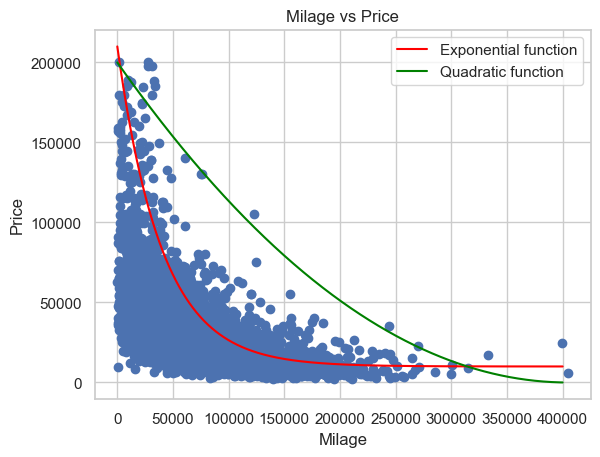

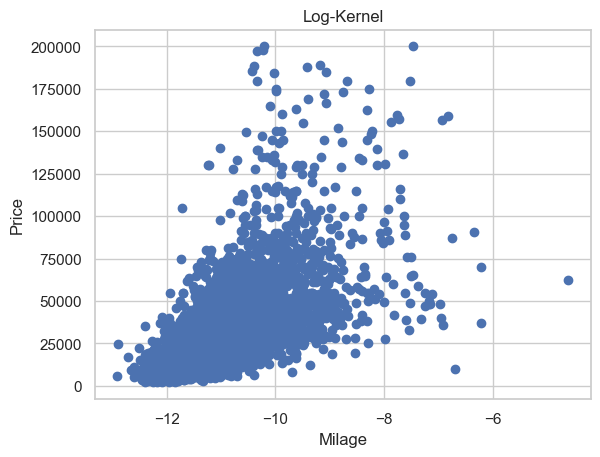

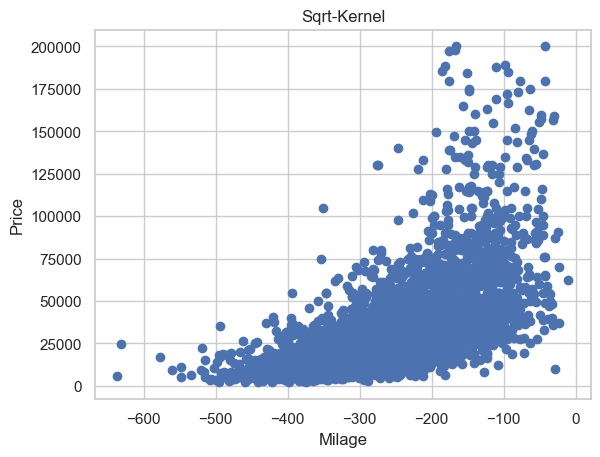

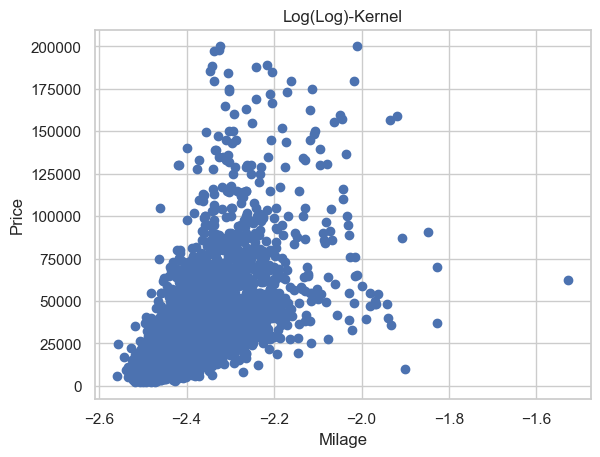

In [45]:
# Your code here
import matplotlib.pyplot as plt

# Scatter plot: milage vs price
plt.scatter(df['milage'], df['price'])
plt.xlabel('Milage')
plt.ylabel('Price')
plt.title('Milage vs Price')

# fitting some functions
def exponential_function(x):
    return 200000 * np.exp(-1/40000*x) + 10000

def quadratic_function(x):
    return 0.0000012195*x**2 - 0.9877554878*x + 200000

x_values = np.linspace(0, 400000, 10000)

plt.plot(x_values, exponential_function(x_values), color='red', label='Exponential function')
plt.plot(x_values, quadratic_function(x_values) , color='green', label='Quadratic function')
plt.legend()
plt.show()

# look at the chosen kernel functions on the data
plt.scatter(-np.log(df['milage']), df['price'])
plt.title('Log-Kernel')
plt.xlabel('Milage')
plt.ylabel('Price')
plt.show()

plt.scatter(-np.sqrt(df['milage']), df['price'])
plt.title('Sqrt-Kernel')
plt.xlabel('Milage')
plt.ylabel('Price')
plt.show()

plt.scatter(-np.log(np.log(df['milage'])), df['price'])
plt.title('Log(Log)-Kernel')
plt.xlabel('Milage')
plt.ylabel('Price')
plt.show()

**Answer:**

The curve looks pretty much exponentially decreasing as illustrated by the fittet exponential funtion (red). Therefore I use a log and a log(log) kernel. Additionally I try a square root kernel. I plottet the effect of my chosen kernel-function on the milage data.

For each kernel function, create a copies of your normalized train sets, test sets and the normalized target car, and extend them with the transformed *milage* feature. Call the _model_training_ function with a linear regression model. Show the errors (MAE, RMSE) and predict the price of the target car. Which of the kernels performs best?

**[3 points]**

In [46]:
# Your code here

# copying the data
X_train_copy = X_train_transformed_df.copy()
X_test_copy = X_test_transformed_df.copy()
car_copy = target_car.copy()
X_test_reg_copy = X_test_reg.copy()
X_test_copy.reset_index(drop=True, inplace=True)
X_test_reg_copy.reset_index(drop=True, inplace=True)
car_copy.reset_index(drop=True, inplace=True)

# My 3 chosen kernel functions
def log_kernel(x):
    return -np.log(x)

def sqrt_kernel(x):
    return -np.sqrt(x)

def log_log_kernel(x):
    return -np.log(np.log(x))

# Adding the new milage features to the transformed data set
X_train_copy['milage_log'] = log_kernel(X_train_reg['milage'])
X_train_copy['milage_sqrt'] = sqrt_kernel(X_train_reg['milage'])
X_train_copy['milage_log_log'] = log_log_kernel(X_train_reg['milage'])

X_test_copy['milage_log'] = log_kernel(X_test_reg_copy['milage'])
X_test_copy['milage_sqrt'] = sqrt_kernel(X_test_reg_copy['milage'])
X_test_copy['milage_log_log'] = log_log_kernel(X_test_reg_copy['milage'])

car_copy['milage_log'] = log_kernel(car['milage'])
car_copy['milage_sqrt'] = sqrt_kernel(car['milage'])
car_copy['milage_log_log'] = log_log_kernel(car['milage'])
        
# transforming the new milage features
scaler = StandardScaler()
X_train_copy[['milage_log', 
              'milage_sqrt', 'milage_log_log']] = scaler.fit_transform(X_train_copy[['milage_log', 
                                                                                     'milage_sqrt', 'milage_log_log']])
X_test_copy[['milage_log', 
             'milage_sqrt', 'milage_log_log']] = scaler.transform(X_test_copy[['milage_log', 
                                                                               'milage_sqrt', 'milage_log_log']])
car_copy[['milage_log', 
          'milage_sqrt', 'milage_log_log']] = scaler.transform(car_copy[['milage_log', 
                                                                         'milage_sqrt', 'milage_log_log']])

# choosing the correct features for each of the new datasets
X_train_log = X_train_copy.drop(columns = ['milage', 'milage_sqrt', 'milage_log_log'])
X_train_sqrt = X_train_copy.drop(columns = ['milage', 'milage_log', 'milage_log_log'])
X_train_log_log = X_train_copy.drop(columns = ['milage', 'milage_log', 'milage_sqrt'])

X_test_log = X_test_copy.drop(columns = ['milage', 'milage_sqrt', 'milage_log_log'])
X_test_sqrt = X_test_copy.drop(columns = ['milage', 'milage_log', 'milage_log_log'])
X_test_log_log = X_test_copy.drop(columns = ['milage', 'milage_log', 'milage_sqrt'])
                                                    
car_log = car_copy.drop(columns = ['milage', 'milage_sqrt', 'milage_log_log'])
car_sqrt = car_copy.drop(columns = ['milage', 'milage_log', 'milage_log_log'])
car_log_log = car_copy.drop(columns = ['milage', 'milage_log', 'milage_sqrt'])

# fitting linear regression for the log kernel
linear_regressor = LinearRegression()
grid_params = {} 
linear_grid, linear_mae, linear_rmse, linear_best_params = model_training(
    linear_regressor, X_train_log, y_train_reg, X_test_log, y_test_reg, grid_params
)
print("Log-kernel")
print(f"Linear Regression Mean Absolute Error: {linear_mae}")
print(f"Linear Regression Root Mean Square Error: {linear_rmse}")
car_price_prediction = linear_grid.predict(car_log)
print(f"Predicted Price for the Target Car: {car_price_prediction[0]}")      

# fitting linear regression for the sqrt kernel
linear_grid, linear_mae, linear_rmse, linear_best_params = model_training(
    linear_regressor, X_train_sqrt, y_train_reg, X_test_sqrt, y_test_reg, grid_params
)
print("Sqrt-kernel")
print(f"Linear Regression Mean Absolute Error: {linear_mae}")
print(f"Linear Regression Root Mean Square Error: {linear_rmse}")
car_price_prediction = linear_grid.predict(car_sqrt)
print(f"Predicted Price for the Target Car (Linear Regression): {car_price_prediction[0]}")   

# fitting linear regression for the log(log) kernel
linear_grid, linear_mae, linear_rmse, linear_best_params = model_training(
    linear_regressor, X_train_log_log, y_train_reg, X_test_log_log, y_test_reg, grid_params
)
print("Log(Log)-kernel")
print(f"Linear Regression Mean Absolute Error: {linear_mae}")
print(f"Linear Regression Root Mean Square Error: {linear_rmse}")
car_price_prediction = linear_grid.predict(car_log_log)
print(f"Predicted Price for the Target Car (Linear Regression): {car_price_prediction[0]}")   

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END ..................................., score=0.581 total time=   0.0s
[CV 2/5] END ..................................., score=0.579 total time=   0.0s
[CV 3/5] END ..................................., score=0.500 total time=   0.0s
[CV 4/5] END ..................................., score=0.499 total time=   0.0s
[CV 5/5] END ..................................., score=0.552 total time=   0.0s
Log-kernel
Linear Regression Mean Absolute Error: 12226.709483139148
Linear Regression Root Mean Square Error: 20526.124567139428
Predicted Price for the Target Car: 37005.9022447281
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END ..................................., score=0.558 total time=   0.0s
[CV 2/5] END ..................................., score=0.575 total time=   0.0s
[CV 3/5] END ..................................., score=0.501 total time=   0.0s
[CV 4/5] END ..................................., s

**Answer:**

The log and the log(log) kernel both perform good. The log(log) kernel was the best with MAE = 12136.46 and RMSE =  20526.64.

### (vii) Neural networks

While you are working on your predictive models, N. walks by. With a critical look on your screen, N. says: "Linear regression is so boring. Nowadays, deep learning is all the rage. Ever heard of ChatGPT and transformer models? Come on, at least you should train a neural network. Watch me, I'll show you," N. says, grabs your keyboard and starts typing.

In [47]:
# Since I can't change the code below and I don't want to change the names of my variables everywhere
# I have to assign the new names

normalized_x_train = X_train_transformed_df
normalized_x_test = X_test_transformed_df
y_train = y_train_reg
y_test = y_test_reg
normalized_car = target_car

In [48]:
### Provided Code (do not change!)
from sklearn.neural_network import MLPRegressor

param_grid_nn = {'activation': ['identity'],
              "early_stopping": [True],
              "validation_fraction": [0.1],
              "learning_rate": ["adaptive"],
              'solver' : ['lbfgs'],
              'hidden_layer_sizes': [(2,1), (5,1), (20,1), (100,5)]
             }
grid_nn, mean_abs_err_nn, rms_err_nn, best_params_nn = model_training(
    MLPRegressor(max_iter = 10000), normalized_x_train, y_train, normalized_x_test, y_test, param_grid_nn
)
print("Mean absolute error: {}".format(mean_abs_err_nn))
print("Root-mean-square error: {}".format(rms_err_nn))
print("Predicted Price of the target car: {}".format(grid_nn.predict(normalized_car)))
print("Params of best model: {}".format(best_params_nn))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END activation=identity, early_stopping=True, hidden_layer_sizes=(2, 1), learning_rate=adaptive, solver=lbfgs, validation_fraction=0.1;, score=0.520 total time=   0.0s
[CV 2/5] END activation=identity, early_stopping=True, hidden_layer_sizes=(2, 1), learning_rate=adaptive, solver=lbfgs, validation_fraction=0.1;, score=0.545 total time=   0.0s
[CV 3/5] END activation=identity, early_stopping=True, hidden_layer_sizes=(2, 1), learning_rate=adaptive, solver=lbfgs, validation_fraction=0.1;, score=0.475 total time=   0.0s
[CV 4/5] END activation=identity, early_stopping=True, hidden_layer_sizes=(2, 1), learning_rate=adaptive, solver=lbfgs, validation_fraction=0.1;, score=0.451 total time=   0.0s
[CV 5/5] END activation=identity, early_stopping=True, hidden_layer_sizes=(2, 1), learning_rate=adaptive, solver=lbfgs, validation_fraction=0.1;, score=0.501 total time=   0.0s
[CV 1/5] END activation=identity, early_stopping=True, 

Execute the code above and interpret the result in comparison to your previous results. In particular, discuss the choice of the activation function and the size of the hidden layers.

*Hint:* Set the verbose parameter of the grid search (e.g. , to 3) to get more detailed information on the model training.

**[4 points]**

**Answer:**

The result is similar to the linear regression without kernel which is expected since we are using the linear activation function and therefore our entire model is linear. We are using 2 hidden layers where the first one is bigger and the second one is smaller. Since cross-validation introduces randomness the optimal parameters for the hidden layers might change. In general we can see that increasing the neurons per layers has almost no effect on the cv-scores. Adding more neurons doesn't provide a lot of additional benefits as our data appears to be not "too complex".

## (e) Discussion **[6 points]**

Summarize your findings and discuss limitations of the different prediction approaches. In your discussion, not only refer to the predicted price of the running example and the confidence of your prediction, but also to the methods in general.

- Based on the general methodologies, which approach would you prefer and why?
- Which approach performed best on the given example?
- Are your results consistent with this view?
- How would you explain the margin of errors in each approach?
- What can you deduce from the differences between MAE and RMSE?
- Are there limitations regarding the comparability of the approaches?

  
**[6 points]**

**Answer:**

Based on the general methodologies, which approach would you prefer and why?

- We are looking for a regression task and basic decision trees are not made for regression. We used a work around by defining bins to make the regression task a classification task but still the decision tree is expected to perform worse than actual regression algorithms. One positive note for decision trees is their interpretability especially for smaller trees.
- DBSCAN is a clustering tool. It is not used for prediction. Again we did some kind of work around to use the clustering for a classification task but this is definitely worse than actual regression.
- Linear regression (with kernel): This is a good algorithm for regression especially if the structure in our data is linear. It makes a lot of sense for the task at hand. Using the kernel to transform the data makes the method applicable for non-linear which should lead to even better results (with a fitting kernel function).
- Neural Networks, specifically the MLPRegressor is a good choice for this regression task. It is a powerful regressor.
- To conclude: I prefer Linear Regression (especially with kernel) and Neural Network over DBSCAN and Decision Tree for this task.

Which approach performed best on the given example?

- Linear Regression with a logarithmic kernel function performed best
- Here are all results sorted by how well they did on the metrics MAE and RMSE:
    1. Linear Regression with a logarithmic kernel function (log(log)): MAE = 12136.46, RMSE = 20526.63
    2. Linear Regression without a kernel function/ Neural Network: MAE = 13698.62, RMSE = 21448.81
    4. Decision Tree: MAE = 15760.11, RMSE = 28965.96
    5. DBSCAN: MAE = 20141.91, RMSE = 30149.77
    6. Baseline: MAE = 20509.65, RMSE = 30579.40

Are your results consistent with this view?

- The results are very much in line with what I expected. It is good to see that all algorithms perform better than the baseline. As mentioned above we did expect dbscan and Decision Tree to perform worse than Linear Regression and Neural Networks which was in fact true. We were also expecting that introducing kernels would lead to significantly better performances which proved to be true as well.

How would you explain the margin of errors in each approach?

- Baseline: Predicting every car to have the average price is obviously a very bad way of doing regression. It is expected to have the largest errors especially in the RMSE since the RMSE penalizes larger errors more heavily. And when we predict the very expensive cars (i.e. 200,000) to have the mean price (about 35,000) the errors become very large.
- DBSCAN: As mentioned above DBSCAN is not a regression tool. The way of using the 40 clusters, calculating their mean price and using this for classification is expected to lead to high errors. In one cluster the cars might be very similar (for example all Porsche) but still have a wide range in the price. Then calculating the mean of the cluster is not a good regressor for the actual price. But the worst thing is the noice which is almost 40% of all data points and they might have nothing in common. Predicting a car with the noice cluster is basically the same as using the baseline. Therefore the results are only slightly better than for baseline.
- Decision Tree: As explained above a Decision Tree is used for classification and not for regression. We take the average of the bins to predict the price. With this in mind we take a look at the distribution of our data and see that there are a lot more cars with lower prices (75% below 45,000) than with high prices (especially between 80,000 and 200,000). The number of cars with higher prices is exponentially decreasing. Therefore the Decision Tree focuses on classifying the cheap cars correctly and "doesn't really care" about the expensive cars. This becomes evident when looking at the tree of size 4 where it is observable that the highest bin that is predicted with a leaf note is (80000, 100000]. The result is that the MAE is notably smaller than for DBSCAN while the RMSE is still quite large because the Decision tree makes huge mistakes for very expensive cars.
- Linear Regression (without kernel): This is a linear regression model suitable for the regression task at hand. In contrast to Decision Trees this model has a way to predict the expensive cars as well as the cheap cars leading to a very big improvement in the RMSE and a smaller but significant improvement in the MAE compared to Decision Trees. The main reason is that the model makes less of the very big mistakes that Decision Tree and DBSCAN made. The big advantage of this model is that it can actually do regession so we don't have a fixed numbers to predict for each car but we have the full range of prices at our disposal.
- Neural Network: Basically the same reasoning as for Linear Regression applies since it is also a regression model used with a linear activation function. Therefore we can also observe the same results in the errors.
- Linear Regression with a logarithmic kernel function: This is similar to Linear Regression with the improvment of not assuming linearity in the data anymore. Since we can model a non linear relationship of our data the confidence in our prediction increases again.

What can you deduce from the differences between MAE and RMSE?

- As mentioned above RMSE penalizes larger errors more heavily than MAE. That means when we see a big gap (RMSE >> MAE) we made some very large mistakes while a small gap is a result of none (or only very few) very big mistakes.
- In our case a small MAE and big RMSE could mean that we did a bad job predicting the very expensive cars (there are only a few) while doing well on the cheaper cars.
- We have seen the biggest gap between MAE and RMSE in this example for Decision Tree where the aforementioned applies (can't predict the very expensive cars).

Are there limitations regarding the comparability of the approaches?

- First of all all our approaches are towards the same task of predicting the price of cars so in general the results are comparable.
- However we are comparing 1 classification, 1 clustering and 2 regression models on a regression task which leads to the obvious result that the regression models are better. Classification and clustering algorithms are not comparable to regression algortihms on a regression task. You also wouldn't compare the best swimmer with the best marathon runner on the task of running a marathon (just as an example). That would be an unfair comparism.
- So you can NOT deduce that Decision Trees or DBSCAN are bad in general (like the swimmer being very good at swimming if we consider the example above). These algorithms are just bad for regression because that's not their main task.
- Additionally we testet the different approaches with different feature selections which might add extra bias.

Having completed your extensive work on predicting prices, you give W. a call to report your findings. W. is excited to hear about your results, and promises to consider your suggestions. 


# Q4: Predicting time-to-sale **[16 points]**

**ReDrive** has just rented a small area parking area in front of the facility with unused space for ten cars. Your new project is an exhibition of selected cars on that space. For a one-time commission, sellers can drive up their car there and your company will market the car also locally.

To maximize turnover by commissions, your business strategy is to exhibit cars there that are likely to be resold quickly. You decide that the cars on display should have an expected selling time of at most 30 days.

## (a) Data preparation **[4 points]**

In this task, we use the dataset **used_cars_reselling_states.csv**. This is an extension of the working dataframe used so far, also describing when a car has been registered for reselling (*registration_date*), when it was successfully resold (*reselling_date*), and the number of days from registration to reselling (*reselling_time*).

Run the code below. The code loads the dataframe, filters out instances without a well-defined outcome for our classification problem, and applies oversampling to the dataframe to circumvent a class imbalance problem.

In [49]:
### Provided Code (do not change!)
import pandas as pd
df = pd.read_csv("used_cars_reselling_states.csv")
df.dropna(subset=["reselling_date"], inplace=True)

# Oversample to circumvent class imbalance 
df_fast = df[df['reselling_time'] <= 30]
df_notfast = df[df['reselling_time'] > 30]
sample_size = len(df_notfast) - len(df_fast)
random_sample = df_fast.sample(n=sample_size, replace=True)
df = pd.concat([df, random_sample], ignore_index=True)

### (i) Target feature creation

Use the column *reselling_time* to define a binary categorical (boolean) feature according to the description above and append this feature to the dataframe. 

**[1 point]**

In [50]:
# Your code here
df['fast_reselling'] = np.where(df['reselling_time'] <= 30, True, False)

### (ii) Sensitivity and Specificity

You have learned about various quality metrics for classifiers.

Briefly illustrate the terms *sensitivity* and *specificity* in the context of the classification problem of fast reselling cars. Suggest which of these metrics is more important for the classifier and provide a justified reason for your suggestion. 

**[2 points]**

**Answer:**

- Sensitivity: The ability of the classifier to correctly classify positive samples. In our case this is ability to classify fast reselling cars as positive. The sensitivity increases when the true positives increase or the false negatives decrease.
- Specificity: The ability of the classifier to correctly classify negative samples. In our case this is the ability to classify cars that are not fast reselling as negative. In other words this is the ability of the classifier to Not label the cars that are slow in reselling as positives. The specificity increases when the true negatives increase or the false positives decrease.

In our problem of the fast reselling cars we only have 10 spaces and have to decide for 10 cars out of a big dataset which are likely to sell fast. When choosing the cars we need to be very sure that a car that has the value fast reselling is actually fast reselling so the most important thing for us is to minimize the false positives. We don't need that many true positives because we only have 10 spaces. Therefore the most important thing is to maximize the specificity since the specificity increases when fp decreases.

### (iii) Data transformation for classification problem

Use *milage*, *model_year* and *price* as descriptive features and your binary feature as the target feature. Create a test and training set like before. For the train-test split, use again `train_test_split` from *sklearn* with arguments `random_state=3` and `test_size=0.05`. 

Normalize the training and test sets. Use the `StandardScaler` from *sklearn* for normalization.

**[1 point]**

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
## Your code here
X_classification = df[['milage', 'model_year', 'price']]
y_classification = df['fast_reselling']

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification, y_classification, test_size=0.05, random_state=3
)

# Normalize the data
scaler = StandardScaler()
X_train_class = scaler.fit_transform(X_train_class)
X_test_class = scaler.transform(X_test_class)
X_train_class_df = pd.DataFrame(X_train_class, columns=['milage', 'model_year', 'price'])
X_test_class_df = pd.DataFrame(X_test_class, columns=['milage', 'model_year', 'price'])

X_train_class_df

,milage,model_year,price
0,1.916369,0.056160,-0.695981
1,-0.739899,-2.275644,-0.566538
2,0.292981,-2.993123,-0.917113
3,0.603409,-0.123210,-1.060939
4,-0.330174,0.773638,0.463900
...,...,...,...
3882,0.430744,0.235529,-0.728342
3883,-0.090318,-0.481949,-0.710364
3884,-1.066605,1.132377,-0.171018
3885,2.467013,-1.020058,-0.965654


## (b) Classifiers **[10 points]**

### (i) Model training

Train two classifiers: 
- A Logistic Regressor,
- A Support Vector Machine.

 **[1 point]**

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# Your code here
logistic_classifier = LogisticRegression()
svm_classifier = SVC()

logistic_classifier.fit(X_train_class_df, y_train_class)
svm_classifier.fit(X_train_class_df, y_train_class)

SVC()

### (ii) Evaluation, Part 1

For both classifiers, show the confusion matrix. 

**[2 points]**

Logistic Regression Confusion Matrix:


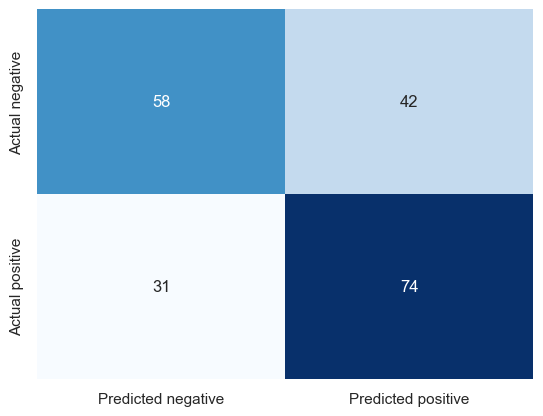

[[58 42]
 [31 74]]

Support Vector Machine Confusion Matrix:


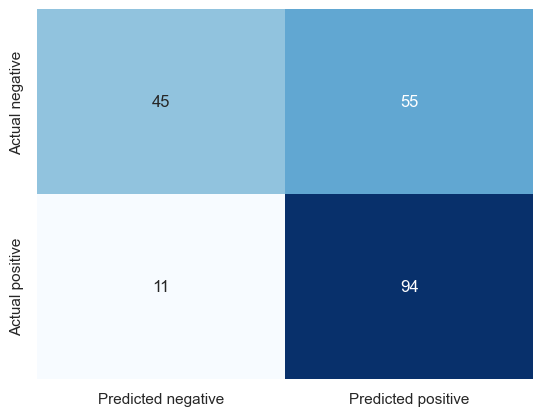

[[45 55]
 [11 94]]


In [53]:
# Your code here
from sklearn.metrics import confusion_matrix

logistic_predictions = logistic_classifier.predict(X_test_class_df)
svm_predictions = svm_classifier.predict(X_test_class_df)

logistic_conf_matrix = confusion_matrix(y_test_class, logistic_predictions)
svm_conf_matrix = confusion_matrix(y_test_class, svm_predictions)

print("Logistic Regression Confusion Matrix:")
sns.heatmap(logistic_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted negative', 'Predicted positive'],
            yticklabels=['Actual negative', 'Actual positive'])
plt.show()
print(logistic_conf_matrix)

print("\nSupport Vector Machine Confusion Matrix:")
sns.heatmap(svm_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted negative', 'Predicted positive'],
            yticklabels=['Actual negative', 'Actual positive'])
plt.show()
print(svm_conf_matrix)

Compute, if possible, precision, recall and F1-score of each classifier. Also, compute sensitivity and specificity of each classifier.

**[2 points]**

In [54]:
# Your code here
from sklearn.metrics import recall_score, precision_score, f1_score 

print("\nLogistic Regression:")
print("recall",recall_score(y_test_class, logistic_predictions))
print("precision",precision_score(y_test_class, logistic_predictions))
print("f1_score",f1_score(y_test_class, logistic_predictions))
tn, fp, fn, tp = confusion_matrix(y_test_class, logistic_predictions).ravel()
sensitivity_logistic = tp / (tp + fn)
specificity_logistic = tn / (tn + fp)
print("Sensitivity:", sensitivity_logistic)
print("Specificity:", specificity_logistic)

print("\nSVM:")
print("recall",recall_score(y_test_class, svm_predictions))
print("precision",precision_score(y_test_class, svm_predictions))
print("f1_score",f1_score(y_test_class, svm_predictions))
tn, fp, fn, tp = confusion_matrix(y_test_class, svm_predictions).ravel()
sensitivity_svm = tp / (tp + fn)
specificity_svm = tn / (tn + fp)
print("Sensitivity:", sensitivity_svm)
print("Specificity:", specificity_svm)


Logistic Regression:
recall 0.7047619047619048
precision 0.6379310344827587
f1_score 0.6696832579185522
Sensitivity: 0.7047619047619048
Specificity: 0.58

SVM:
recall 0.8952380952380953
precision 0.6308724832214765
f1_score 0.7401574803149606
Sensitivity: 0.8952380952380953
Specificity: 0.45


Would you choose any of the trained classifiers for application on the described problem? If yes, which one? Justify your answer.

**[1 point]**

**Answer:**

Non of the trained classifiers are good for our applicatication since the specificity for both is very low. Therefore I decide to choose non of the classifiers. However if I had to choose one of the classifiers I would choose the logistic regression since it has a higher specificity. 

### (iii) Evaluation, Part 2

Besides the *predict* method to decide for the class label of an instance, a `LogisticRegression` model from *sklearn* offers the method `predict_proba`. This method takes a list of instances to be classified and returns a list of tuples. Each tuple has two entries: The first entry is the probability for the respective instance to be classified as negative and the second entry is the probability for the instance to be classified as positive. Thus, the entries of each tuple sum up to 1.

As you learned in the lecture, we can vary the outcome of a logistic regression classifer by setting a threshold. Instances are labeled as positive if their probability for a positive label is greater than or equal to the threshold.

Define the body of the function *threshold_to_rates* below. This function receives a threshold between 0 and 1, and then classifies the test data based on the threshold and the outcome of the instances under the `predict_proba` method of your trained classifier. The function must return a tuple where the first entry is the true positive rate and the second entry is the false positive rate with respect to the given configuration.

**Input**:
- **h**: A real number within the interval $[0,1]$.

**Output**:
- **TPR**: The true positive rate of your test data set, based on the given threshold.
- **FPR**: The false positive rate of your test data set, based on the given threshold. 

**[3 points]**

In [55]:
def threshold_to_rates(h):
    tpr = 0
    fpr = 0
    # # # # # # # # # #
    # Your code here  #
    # # # # # # # # # #
    probabilities = logistic_classifier.predict_proba(X_test_class_df)[:, 1]
    predictions = probabilities >= h
    
    tp = sum((predictions == 1) & (y_test_class == 1))
    fp = sum((predictions == 1) & (y_test_class == 0))
    tn = sum((predictions == 0) & (y_test_class == 0))
    fn = sum((predictions == 0) & (y_test_class == 1))
    
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    # # # # # # # # # #
    return (tpr, fpr)

Having specified the *threshold_to_rates* function, execute the code box below to plot the ROC curve of your classifier.

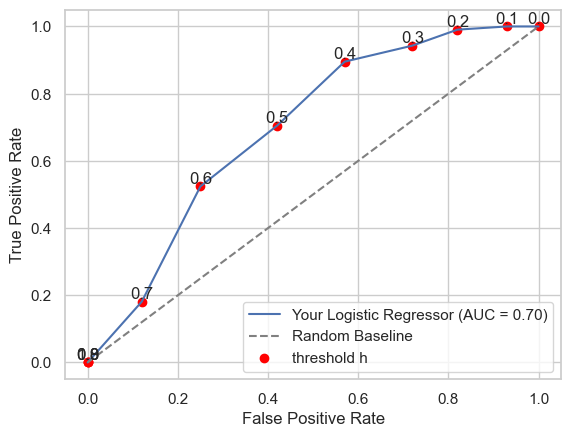

In [56]:
# Given code (Do not change)
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
steps =  np.arange(1.0, -0.1, -0.1)
steps = [round(h*10)/10 for h in steps]
data = {
    h : threshold_to_rates(h)
    for h in steps
}

fpr = [data[h][1] for h in steps]
tpr = [data[h][0] for h in steps]

roc_auc = metrics.auc(fpr, tpr)
roc_display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Your Logistic Regressor')
roc_display.plot()

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Baseline')
plt.scatter(fpr, tpr, color='red', marker='o', label='threshold h')
for i, label in enumerate(steps):
    plt.text(fpr[i], tpr[i], label, fontsize=12, ha='center', va='bottom')

plt.legend()
plt.show()

Interpret the plot. Is there a threshold you would choose for the application of the classifier on the described problem? Justify your answer.

**[1 point]**

**Answer:**

As our threshold decreases we see that both the false positive rate and the true positive rate increases. We are always higher than our baseline which means that we are better than random guessing.

- On the left handside of the plot we are setting a high threshold so we only predict the samples as positive when we are very sure that they are positives. Therefore the fpr is very low but we also miss a lot of positive samples so the tpr is also low.
- On the right handside we predict almost everything as positives leaving only the once where we are very sure that they are negative as negative. Therefore both the fpr and tpr are high.

For our application we want to be very sure about the positives therefore setting a high threshold. I would choose the highest value for which we classifiy 10 positive cars since we don't need to have more positives and we want to be very sure. Judging by the plot this might be the case for threshold between 0.8 and 0.6.

## (c) Discussion **[2 points]**

Summarize your findings. Discuss limitations and improvement potentials. 

**[2 points]**

**Answer:**

Note that there is some randomness involved so the results might not be completely similar but similar trends will be visible.

Summary: 
- Both classifiers have a high sensitivity with SVM having the higher score (about 0.9).
- Both have a low specificity with Logistic Regression being the higher one (0.57).
- The F1-score of both models is decent and pretty similar (around 0.7)
- Both models are not well suited for the classification task at hand because the specificity is very important for us.
- We have seen that using a high threshold can improve the Logistic Regression for our task.

Limitations and improvements:
- We only compared two different classifiers but there are a lot more very strong classifiers that we should try for this task.
- We just used 3 features while having a lot more features in our data set. We should take a closer look at our features to select which once to use.
- We didn't tune any of the hyperparameters of our models. We should use gridsearch or similar algorithms to decide for the best hyperparameters.